In [ ]:
%matplotlib inline

project_name= 'CATDI'
sbj_name = 'DBSTRD014' 
path='/Users/sophiapouya/workspace/bcm'

project_root=path+'/'+project_name
data_root= project_root+'/neuralData'
result_root= project_root+'/Results'

import os
os.makedirs(result_root, exist_ok=True)
import sys
import scipy.io
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import glob, re
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.model_selection import LeaveOneOut,KFold,cross_val_score,cross_val_predict
from sklearn.linear_model import LinearRegression,ElasticNet,Ridge,ElasticNetCV, Lasso
from scipy import stats
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm
import multiprocess as mp
from statsmodels.stats.multitest import fdrcorrection
import warnings
import random
from scipy.stats import iqr
import datetime as dt
from datetime import datetime,date,time
from matplotlib import rc
rc={'font.size' : 22, 
    'font.family' : "Arial",
    'axes.labelsize': 22,   
    'legend.fontsize': 22, 
    'axes.titlesize': 22, 
    'xtick.labelsize': 22, 
    'ytick.labelsize': 22}
sns.set(style="white", rc=rc)

log_tran=True
savemode=True
# get behavioral data (CATDI score)
Scoredata=os.path.join(project_root,'CATDI_scores.xlsx')
ScoreList =  pd.read_excel(Scoredata,sheet_name=sbj_name)
ScoreList = ScoreList[ScoreList.Result != 'incomplete']
if sbj_name == 'DBSTRD001':
    # Extract numeric part before any parentheses
    ScoreList['Score'] = ScoreList['Result'].astype(str).str.extract(r'([\d\.]+)').astype(float)
    ScoreList = ScoreList[ScoreList['Name'] != 'CATDI_run-08_blk-04']
else:
    ScoreList['Score'] = ScoreList['Result'].astype(float)
if sbj_name=='DBSTRD002': 
    ScoreList = ScoreList[ScoreList['Name'] != 'CATDI_run-05_blk-04'] #no 2kHz neural data
    ScoreList = ScoreList[ScoreList['Name'] != 'CATDI_run-07_blk-05'] #nosies in highgamma
    ScoreList = ScoreList[ScoreList['Name'] != 'CATDI_run-03_blk-02'] #15Hz noise
    ScoreList = ScoreList[ScoreList['Name'] != 'CATDI_run-03_blk-03'] #15Hz noise
if sbj_name=='DBSTRD006':
    ScoreList = ScoreList[ScoreList['Name'] != 'CATDI_date-02-13-2022_time-15-50-56'] #no neural data
    ScoreList = ScoreList[ScoreList['Name'] != 'CATDI_date-02-09-2022_time-12-45-13'] #30kHz
    ScoreList = ScoreList[ScoreList['Name'] != 'CATDI_date-02-09-2022_time-14-01-20'] #30kHz

# if sbj_name == 'DBSTRD008':
#     ScoreList = ScoreList[ScoreList['Name'] != 'CATDI_date-10-24-2022_time-14-42-53'] 
#     ScoreList = ScoreList[ScoreList['Name'] != 'CATDI_date-10-26-2022_time-10-58-16']
#     ScoreList = ScoreList[ScoreList['Name'] != 'CATDI_date-10-22-2022_time-18-44-25']
    
# Now y is guaranteed numeric
y = ScoreList['Score'].values
bn=ScoreList['Name'].values #only get neural data from complete blocks

def get_elecs(path, project_name, sbj_name, bn):
    """Map a ScoreList name to originalData/* folder, load master_*.mat."""
    short_name = bn[0]  # e.g., CATDI_run-01_blk-01 or CATDI_date-02-11-2022_time-11-44-18
    subject_dir = os.path.join(path, project_name, 'neuralData', 'originalData', sbj_name)
    matches = []

# --- NEW LOGIC FOR DBSTRD011 / DBSTRD014 (Direct Match) ---
    if sbj_name in ['DBSTRD011', 'DBSTRD014']:
        # For these subjects, the 'short_name' from ScoreList is the full, exact folder name.
        # We perform a direct glob search using the full name, which is the most robust match.
        
        # We assume the short_name is correct, but use glob for safety.
        name_pattern = short_name
        pattern = os.path.join(subject_dir, name_pattern)
        matches.extend(glob.glob(pattern))
        
        if matches:
            block_directory = sorted(matches)[0]
            master_match = glob.glob(os.path.join(block_directory, "master_*.mat"))
            if not master_match:
                raise FileNotFoundError(f"No master_*.mat in: {block_directory}")
        
            master = scipy.io.loadmat(master_match[0])
            elecs = master['master_vars']['elecs'][0][0][0]
            nchan = master['master_vars']['nchan'][0][0][0][0]
            return elecs, nchan
        # If no match is found, continue to the original logic as a fallback (though unlikely)
    # --- END NEW LOGIC ---
    
    # First try run/blk-style
    m_run_num = re.search(r'run-(?:Day)?(\d+)', short_name)
    m_blk_num = re.search(r'blk-(\d+)', short_name)

    if m_run_num and m_blk_num:
        run_num = int(m_run_num.group(1))
        blk_num = int(m_blk_num.group(1))
        run_tokens = [f"run-{run_num:02d}", f"run-{run_num}", f"run-Day{run_num}"]
        blk_tokens = [f"blk-{blk_num:02d}", f"blk-{blk_num}"]
        for cat in ["CATDI", "CAT-DI"]:
            for r in run_tokens:
                for b in blk_tokens:
                    pattern = os.path.join(subject_dir, f"*{cat}*{r}*{b}*")
                    matches.extend(glob.glob(pattern))

    # Fallback: datetime-style (DBSTRD006)
    if not matches and ("date-" in short_name and "time-" in short_name):
        date_part = re.search(r'(date-\d{2}-\d{2}-\d{4})', short_name)
        time_part = re.search(r'(time-\d{2}-\d{2}-\d{2})', short_name)
        if date_part and time_part:
            for cat in ["CATDI", "CAT-DI"]:
                pattern = os.path.join(subject_dir, f"*{cat}*{date_part.group(1)}*{time_part.group(1)}*")
                matches.extend(glob.glob(pattern))

    if not matches:
        sample = glob.glob(os.path.join(subject_dir, "*CAT*"))[:10]
        raise FileNotFoundError(
            f"No originalData folder for '{short_name}' under:\n  {subject_dir}\n"
            f"Examples I can see:\n  " + "\n  ".join(sample)
        )

    block_directory = sorted(matches)[0]
    master_match = glob.glob(os.path.join(block_directory, "master_*.mat"))
    if not master_match:
        raise FileNotFoundError(f"No master_*.mat in: {block_directory}")

    master = scipy.io.loadmat(master_match[0])
    elecs = master['master_vars']['elecs'][0][0][0]
    nchan = master['master_vars']['nchan'][0][0][0][0]
    return elecs, nchan
elecs,nchan=get_elecs(path,project_name,sbj_name,bn)

df = pd.DataFrame()
channeldata=os.path.join(project_root,'CATDI_electrodes.xlsx')
channelList =  pd.read_excel(channeldata,sheet_name=sbj_name)

import string
cleaned = [item.rstrip(string.digits) for item in channelList['Label'].values]
for idx in np.arange(0,len(cleaned)-1):
    if (cleaned[idx]!=cleaned[idx+1]):
        cleaned[idx]='NaN'
cleaned[len(cleaned)-1]='NaN'
channelList['Bipolar']=cleaned
    
for i_chan in channelList.Electrode.values:
    df.loc[i_chan-1, 'region'] = channelList.loc[channelList.Electrode==i_chan,'area'].values[0]
    df.loc[i_chan-1, 'matter'] = channelList.loc[channelList.Electrode==i_chan,'Grey v White'].values[0]
    df.loc[i_chan-1, 'Electrode'] = channelList.loc[channelList.Electrode==i_chan,'Electrode'].values[0].astype(int)
    df.loc[i_chan-1, 'hemi'] = channelList.loc[channelList.Electrode==i_chan,'Hemisphere'].values[0]
    df.loc[i_chan-1, 'Label'] = channelList.loc[channelList.Electrode==i_chan,'Label'].values[0] 
    df.loc[i_chan-1, 'Bipolar'] = channelList.loc[channelList.Electrode==i_chan,'Bipolar'].values[0] 

df = df[df['region'].notna()]
df = df[df.region != 'Bolt']
#df['Type'] = channelList['Type'].astype(str)
#dbs_mask = df['Type'].str.upper().eq('DBS')
#df = df[(df['matter'].eq('Grey')) | dbs_mask]
df = df[df.matter == 'Grey']
df = df[df.Bipolar!='NaN']  
 
regionlist=['ACC','dlPFC','OFC', 'vmPFC','AMY']#df.region.unique()
dicts_region2chan = {}
for regionname in itertools.combinations(regionlist, 1):
    regionname=regionname[0]
    dicts_region2chan[regionname] = df[df.region.isin([regionname])].index.values
print(dicts_region2chan)

# helper functions
def find_original_folder(path, project_name, sbj_name, block_name):
    """
    Return the actual folder under originalData/<sbj_name>/ that corresponds to a block_name.
    Works for:
      - CATDI_run-01_blk-01
      - CATDI_run-Day3_blk-02
      - CATDI_date-02-11-2022_time-11-44-18
    """
    subject_dir = os.path.join(path, project_name, 'neuralData', 'originalData', sbj_name)
    matches = []

# --- NEW LOGIC FOR DBSTRD011 / DBSTRD014 (Direct Match) ---
    if sbj_name in ['DBSTRD011', 'DBSTRD014']:
        # For these subjects, the 'block_name' is the full, exact folder name.
        name_pattern = block_name
        pattern = os.path.join(subject_dir, name_pattern)
        matches.extend(glob.glob(pattern))
        
        if matches:
            return sorted(matches)[0] # Return immediately if a direct match is found
        
    # 1) run/blk-style (DBSTRD001/002)
    m_run = re.search(r'run-(?:Day)?(\d+)', block_name)
    m_blk = re.search(r'blk-(\d+)', block_name)
    if m_run and m_blk:
        rnum = int(m_run.group(1)); bnum = int(m_blk.group(1))
        run_tokens = [f"run-Day{rnum}", f"run-{rnum:02d}", f"run-{rnum}"]
        blk_tokens = [f"blk-{bnum:02d}", f"blk-{bnum}"]
        for r in run_tokens:
            for b in blk_tokens:
                pattern = os.path.join(subject_dir, f"*CATDI*{r}*{b}*")
                hits = glob.glob(pattern)
                if hits:
                    matches.extend(hits)

    # 2) datetime-style (DBSTRD006)
    if not matches and ("date-" in block_name and "time-" in block_name):
        date_part = re.search(r'(date-\d{2}-\d{2}-\d{4})', block_name)
        time_part = re.search(r'(time-\d{2}-\d{2}-\d{2})', block_name)
        if date_part and time_part:
            pattern = os.path.join(subject_dir, f"*CATDI*{date_part.group(1)}*{time_part.group(1)}*")
            matches.extend(glob.glob(pattern))

    if not matches:
        sample = glob.glob(os.path.join(subject_dir, "*CATDI*"))[:8]
        raise FileNotFoundError(
            f"No originalData folder for '{block_name}' under:\n  {subject_dir}\n"
            "Examples I can see:\n  " + "\n  ".join(os.path.basename(s) for s in sample)
        )

    # deterministic pick in case of multiple
    return sorted(matches)[0]


def find_power_file_by_folder(data_root, sbj_name, folder_basename):
    """
    Map originalData folder name -> powerData file.
    Uses the exact token after 'task-' from the folder to find the *_task-<token>.mat file.
    Tolerates run-DayX vs run-XX and zero padding; DOES NOT touch 'CATDI'.
    """
    base = os.path.join(data_root, 'powerData', sbj_name)
    files = glob.glob(os.path.join(base, "*.mat"))
    if not files:
        raise FileNotFoundError(f"No .mat files under {base}")

    m = re.search(r'task-(.+)$', folder_basename)
    task_token = m.group(1) if m else folder_basename

    # 1) exact token match
    for f in files:
        if f"_task-{task_token}" in os.path.basename(f):
            return f

    # 2) fallback: match by run/blk numbers (DBSTRD001/002)
    run_m = re.search(r'run-(?:Day)?(\d+)', task_token)
    blk_m = re.search(r'blk-(\d+)', task_token)
    if run_m and blk_m:
        rnum = int(run_m.group(1)); bnum = int(blk_m.group(1))
        run_alts = [f"run-Day{rnum}", f"run-{rnum:02d}", f"run-{rnum}"]
        blk_alts = [f"blk-{bnum:02d}", f"blk-{bnum}"]
        for f in files:
            fname = os.path.basename(f)
            if "_task-CATDI" in fname and any(r in fname for r in run_alts) and any(b in fname for b in blk_alts):
                return f

    # 3) fallback: datetime-style (DBSTRD006)
    if "date-" in task_token and "time-" in task_token:
        for f in files:
            fname = os.path.basename(f)
            if f"_task-{task_token}" in fname:
                return f

    raise FileNotFoundError(
        f"No powerData file for task '{task_token}' in {base}\n"
        "Tried exact token and run/blk or date/time fallbacks."
    )

for ii in range(0,len(bn)):
    block_name=bn[ii]
    orig_dir = find_original_folder(path, project_name, sbj_name, block_name)
    folder_basename = os.path.basename(orig_dir)
    powerpath = find_power_file_by_folder(data_root, sbj_name, folder_basename) 
    power = scipy.io.loadmat(powerpath)
    allband_task=power['power']
    allband_task=np.expand_dims(allband_task,axis=2)
    if ii==0:
        allblk_task=allband_task
    else:
        allblk_task=np.concatenate((allblk_task,allband_task), axis=2)
bandlist=np.array(['delta','theta','alpha','beta','gamma','highgamma'])

x=allblk_task

datetimes = []

if sbj_name == 'DBSTRD001':
    for idx in range(len(ScoreList)):
        date_str = str(ScoreList.iloc[idx]['EMUdate'])
        time_str = str(ScoreList.iloc[idx]['Timestamp'])

        if '/' in date_str:
            parts = date_str.split('/', 1)
            date_str = parts[1].strip()

        if date_str.startswith("Thur"):
            date_str = date_str.replace("Thur", "Thu", 1)

        combined = f"{date_str} {time_str}"

        # Try AM/PM first, then fallback to 24-hour with seconds
        try:
            dt_obj = datetime.strptime(combined, "%a %b %d, %Y %I:%M %p")
        except ValueError:
            dt_obj = datetime.strptime(combined, "%a %b %d, %Y %H:%M:%S")

        datetimes.append(dt_obj)

elif sbj_name == 'DBSTRD002':
    # EMUdate is an Excel-style datetime (or string) and Timestamp can be "3:55pm"
    for idx in range(len(ScoreList)):
        raw_date = ScoreList.iloc[idx]['EMUdate']
        raw_time = str(ScoreList.iloc[idx]['Timestamp']).strip()

        # --- date: robustly get a date() from Excel datetime or string ---
        if isinstance(raw_date, (pd.Timestamp, datetime, date)):
            d = pd.to_datetime(raw_date).date()
        else:
            # e.g. "2020-10-20 00:00:00"
            d = pd.to_datetime(str(raw_date), errors='coerce')
            if pd.isna(d):
                # last-resort exact fallback
                d = datetime.strptime(str(raw_date).strip(), "%Y-%m-%d %H:%M:%S")
            d = d.date()

        # --- time: accept "3:55pm", "3:55 pm", "03:55 PM", "15:55:00" ---
        t = None
        # normalize am/pm-only formats by removing spaces and uppercasing
        raw_time_nospace = raw_time.replace(' ', '').upper()
        for fmt, candidate in [
            ("%I:%M%p", raw_time_nospace),     # "3:55PM" / "3:55PM"
            ("%I:%M %p", raw_time.upper()),    # "3:55 PM"
            ("%H:%M:%S", raw_time),            # "15:55:00"
            ("%H:%M", raw_time),               # "15:55"
        ]:
            try:
                t = datetime.strptime(candidate, fmt).time()
                break
            except ValueError:
                continue
        if t is None:
            # pandas fallback for any weird cases
            t = pd.to_datetime(raw_time, errors='raise').time()

        dt_obj = datetime.combine(d, t)
        datetimes.append(dt_obj)

# --- NEW BLOCK FOR DBSTRD011 and DBSTRD014 ---
elif sbj_name in ['DBSTRD011', 'DBSTRD014']:
    for name in ScoreList.Name:
        # Expected format: "...date-YYYYMMDD_time-HHMMSS"
        date_match = re.search(r'date-(\d{8})', name)
        time_match = re.search(r'time-(\d{6})', name)
        
        if date_match and time_match:
            date_str = date_match.group(1) # e.g., '20240717'
            time_str = time_match.group(1) # e.g., '135720'
            
            # Combine the parts and parse
            dt_str = f"{date_str} {time_str}"
            dt_obj = datetime.strptime(dt_str, "%Y%m%d %H%M%S")
            datetimes.append(dt_obj)
        else:
            # Handle problematic names (like np.nan, which is a float here)
            # This is important for synchronization if ScoreList has missing names
            if not isinstance(name, str):
                # We skip missing/non-string names just like we did in the power loop
                # If we skip here, we MUST ensure the final arrays are the correct length.
                # However, since you are iterating over ScoreList.Name, and ScoreList 
                # was already filtered, this should only happen if there is a problem row.
                # If you hit this, it means you need to clean your Excel file (best option)
                # or you must remove the corresponding score from y/ScoreList.
                print(f"  - WARNING: Could not parse date/time from block name: {name}. Skipping.")
                continue

#dbstrd006 pattern applicable 
else:
    dates = []
    times = []
    for name in ScoreList.Name:
        date_part = name[-24:-14]
        time_part = name[-8:]
        dates.append(datetime.strptime(str(date_part), "%m-%d-%Y").date())
        times.append(datetime.strptime(str(time_part), "%H-%M-%S").time())

    for i in range(len(dates)):
        datetimes.append(datetime.combine(dates[i], times[i]))

blockindices=np.arange(0,len(y))
times=[(mydatetimes-datetimes[0]).total_seconds() for mydatetimes in datetimes]
m, b = np.polyfit(times, y, 1)  #m = slope, b=intercept
y_residual=y-(m*np.array(times)+b)
    
if log_tran==True:
    eps = np.finfo(np.float32).tiny   # ~1.18e-38; small enough not to bias
    x = 10*np.log10(np.maximum(x, eps))

# ensure model directory exists
model_dir = os.path.join(result_root, 'model')
os.makedirs(model_dir, exist_ok=True)

if savemode==True:
    ScoreList.to_csv(os.path.join(model_dir, f'{sbj_name}_Scorelist.csv'), index=False)
    df.to_csv(os.path.join(model_dir, f'{sbj_name}_df.csv'), index=False)
    np.savez(os.path.join(model_dir, f'{sbj_name}_Raw.npz'),
             x=x, y=y, y_residual=y_residual,
             allblk_task=allblk_task,
             dicts_region2chan=dicts_region2chan)   
    
print('number of blocks:',len(y))
print('Mean CAT-DI:%s'%format(np.mean(y), '.1f'))
print('std CAT-DI:%s'%format(np.std(y), '.1f'))
print('Max CAT-DI:%s'%format(np.max(y), '.1f'))
print('Min CAT-DI:%s'%format(np.min(y), '.1f'))

chanlist=[]
for regionindex in range(0,len(regionlist)):
    chanlist.append(dicts_region2chan[regionlist[regionindex]])
print([len(chan) for chan in chanlist])
chanlist=np.concatenate(chanlist)
print('Num of contacts:',len(chanlist))
print('Num of features:',len(chanlist)*len(bandlist))


{'ACC': array([17, 18, 86, 87, 88]), 'dlPFC': array([ 36,  37,  38,  39,  40,  52,  53,  54,  55,  56, 110, 112, 124,
       125, 126, 127, 128]), 'OFC': array([26, 27, 28, 58, 59, 60, 62, 63, 64]), 'vmPFC': array([ 42,  43,  44,  45,  48,  49,  98,  99, 100, 101, 102, 103, 114,
       115, 130, 131, 133, 134, 136]), 'AMY': array([ 0,  1,  2,  3, 74, 75, 76, 77])}
number of blocks: 31
Mean CAT-DI:55.7
std CAT-DI:14.2
Max CAT-DI:84.3
Min CAT-DI:23.1
[5, 17, 9, 19, 8]
Num of contacts: 58
Num of features: 348


In [23]:
def plot_CATDI_residual(sbj_name,ax):
    import datetime as dt
    from datetime import datetime
    from datetime import date
    from datetime import time
    import re

    ScoreList=pd.read_csv(result_root+'/model/'+sbj_name+'_Scorelist.csv')
    y=ScoreList['Score'].values
    if sbj_name=='DBSTRD001':
        dates=[date.fromisoformat(x.split()[4]+'-03-'+x.split()[3][:-1]) for x in ScoreList.EMUdate.values]
        times=[datetime.strptime(x, "%H:%M:%S").time() for x in ScoreList.Timestamp.values]
    if sbj_name=='DBSTRD002':
        dates=ScoreList.EMUdate.values.astype('datetime64[D]').astype(datetime)
        times=[datetime.strptime(x[:-2]+' '+x[-2:].upper(), "%I:%M %p").time() for x in ScoreList.Timestamp]
    elif sbj_name in ['DBSTRD006', 'DBSTRD008', 'DBSTRD010']:
        # This logic handles MM-DD-YYYY_H-M-S correctly for these subjects
        dates=[datetime.strptime(str(x), "%m-%d-%Y").date() for x in [item[-24:-14] for item in ScoreList.Name]]
        times=[datetime.strptime(str(x), "%H-%M-%S").time() for x in [item[-8:] for item in ScoreList.Name]]
    elif sbj_name in ['DBSTRD011', 'DBSTRD014']:
        # 🟢 FIX: Correctly parse YYYYMMDD_HHMMSS from the Name column
        dates = []
        times = []
        for name in ScoreList.Name:
            date_match = re.search(r'date-(\d{8})', name) # Find YYYYMMDD
            time_match = re.search(r'time-(\d{6})', name) # Find HHMMSS
            
            if date_match and time_match:
                dates.append(datetime.strptime(date_match.group(1), "%Y%m%d").date())
                times.append(datetime.strptime(time_match.group(1), "%H%M%S").time())
            else:
                raise ValueError(f"Could not parse date/time from block name: {name}")
    # --- End Date/Time Parsing Section ---
    
    datetimes=[]
    for block_index in range(0,len(y)):
        datetimes.append(datetime.combine(dates[block_index], times[block_index]))
        
    blockindices=np.arange(0,len(y))
    times=[(mydatetimes-datetimes[0]).total_seconds() for mydatetimes in datetimes]
    m, b = np.polyfit(times, y, 1)  #m = slope, b=intercept
    y_line=(m*np.array(times)+b)
    y_residual=y-y_line
    unique_dates=list(dict.fromkeys(dates))
    if sbj_name=='DBSTRD001':
        plt.plot_date(datetimes, y_residual,color='deepskyblue')
        rvalue,pvalue=stats.pearsonr(times, y_residual)
        ax.set_yticks([-10,0,10])
    if sbj_name=='DBSTRD002':
        plt.plot_date(datetimes, y_residual,color='tab:orange')
        rvalue,pvalue=stats.pearsonr(times, y_residual)
        ax.set_yticks([-5,0,5])
    if sbj_name=='DBSTRD006':
        plt.plot_date(datetimes, y_residual,color='green')
        rvalue,pvalue=stats.pearsonr(times, y_residual)
        ax.set_yticks([-20,0,20])
    if sbj_name=='DBSTRD008':
        plt.plot_date(datetimes, y_residual,color='red')
        rvalue,pvalue=stats.pearsonr(times, y_residual)
        ax.set_yticks([-20,0,20])
    if sbj_name=='DBSTRD010':
        plt.plot_date(datetimes, y_residual,color='purple')
        rvalue,pvalue=stats.pearsonr(times, y_residual)
        ax.set_yticks([-20,0,20])
    if sbj_name=='DBSTRD011':
        plt.plot_date(datetimes, y_residual,color='blue')
        rvalue,pvalue=stats.pearsonr(times, y_residual)
        ax.set_yticks([-20,0,20])
    if sbj_name=='DBSTRD014':
        plt.plot_date(datetimes, y_residual,color='purple')
        rvalue,pvalue=stats.pearsonr(times, y_residual)
        ax.set_yticks([-20,0,20])
        
    for day_index in range(0,len(unique_dates)):
        if day_index%2==0:   
            ax.axvspan(datetime.combine(unique_dates[day_index],time.fromisoformat('00:00')), datetime.combine(unique_dates[day_index]+ dt.timedelta(days=1),time.fromisoformat('00:00')), facecolor='grey', alpha=0.2)
    ax.set_xticks(ax.get_xticks()[:-1]+0.5)
    ax.set_xticklabels([str(x) for x in np.arange(1,len(ax.get_xticks())+1)])
    ax.set_xlabel('Time (Day)')
    ax.set_ylabel('Depression severity \n(Residual)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.hlines(y=0, color='black',xmin=datetime.combine(unique_dates[0],time.fromisoformat('00:00')), xmax=datetime.combine(unique_dates[-1]+ dt.timedelta(days=1),time.fromisoformat('00:00')),linestyle='--')
    if sbj_name=='DBSTRD001':
        ax.set_title('Patient 1',y=1.2)
    if sbj_name=='DBSTRD002':
        ax.set_title('Patient 2',y=1.2)
    if sbj_name=='DBSTRD006':
        ax.set_title('Patient 3',y=1.2)
def plot_CATDI(sbj_name,ax):
    ScoreList=pd.read_csv(result_root+'/model/'+sbj_name+'_Scorelist.csv')
    y=ScoreList['Score'].values
    if sbj_name=='DBSTRD001':
        dates=[date.fromisoformat(x.split()[4]+'-03-'+x.split()[3][:-1]) for x in ScoreList.EMUdate.values]
        times=[datetime.strptime(x, "%H:%M:%S").time() for x in ScoreList.Timestamp.values]
    elif sbj_name=='DBSTRD002':
        dates=ScoreList.EMUdate.values.astype('datetime64[D]').astype(datetime)
        times=[datetime.strptime(x[:-2]+' '+x[-2:].upper(), "%I:%M %p").time() for x in ScoreList.Timestamp]
    elif sbj_name=='DBSTRD006' or sbj_name == 'DBSTRD008' or sbj_name == 'DBSTRD010':
        dates=[datetime.strptime(str(x), "%m-%d-%Y").date() for x in [item[-24:-14] for item in ScoreList.Name]]
        times=[datetime.strptime(str(x), "%H-%M-%S").time() for x in [item[-8:] for item in ScoreList.Name]]
    elif sbj_name in ['DBSTRD011', 'DBSTRD014']:
        # 🟢 FIX: Correctly parse YYYYMMDD_HHMMSS from the Name column
        dates = []
        times = []
        for name in ScoreList.Name:
            date_match = re.search(r'date-(\d{8})', name)
            time_match = re.search(r'time-(\d{6})', name)
            
            if date_match and time_match:
                dates.append(datetime.strptime(date_match.group(1), "%Y%m%d").date())
                times.append(datetime.strptime(time_match.group(1), "%H%M%S").time())
            else:
                raise ValueError(f"Could not parse date/time from block name: {name}")
    # --- End Date/Time Parsing Section ---

    datetimes=[]
    for block_index in range(0,len(y)):
        datetimes.append(datetime.combine(dates[block_index], times[block_index]))

    unique_dates=list(dict.fromkeys(dates))
    if sbj_name=='DBSTRD001':
        plt.plot_date(datetimes, y,color='deepskyblue')
    if sbj_name=='DBSTRD002':
        plt.plot_date(datetimes, y,color='tab:orange')
    if sbj_name=='DBSTRD006':
        plt.plot_date(datetimes, y,color='green')
    if sbj_name=='DBSTRD008':
        plt.plot_date(datetimes, y,color='purple')
    if sbj_name=='DBSTRD010':
        plt.plot_date(datetimes, y,color='red')
    if sbj_name=='DBSTRD011':
        plt.plot_date(datetimes, y,color='blue')
    if sbj_name=='DBSTRD014':
        plt.plot_date(datetimes, y,color='tan')
        
    for day_index in range(0,len(unique_dates)):
        if day_index%2==0:   
            ax.axvspan(datetime.combine(unique_dates[day_index],time.fromisoformat('00:00')), datetime.combine(unique_dates[day_index]+ dt.timedelta(days=1),time.fromisoformat('00:00')), facecolor='grey', alpha=0.2)
    ax.set_xticks(ax.get_xticks()[:-1]+0.5)
    ax.set_xticklabels([str(x) for x in np.arange(1,len(ax.get_xticks())+1)])
    ax.set_xlabel('Time (Day)')
    ax.set_ylabel('Depression severity')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    if sbj_name=='DBSTRD001':
        ax.annotate(text=' More \nsevere',xy=(-0.34-0.1,0.85),xycoords='axes fraction',fontsize=20)
        ax.annotate(text=' Less \nsevere',xy=(-0.34-0.1,0.05),xycoords='axes fraction',fontsize=20)
        ax.annotate("",xy=(-0.28-0.1,0.18), xycoords='axes fraction',xytext=(-0.28-0.1,0.84), textcoords='axes fraction',arrowprops=dict(arrowstyle='<->',connectionstyle="arc3",color='black', linewidth=1),)
    if sbj_name=='DBSTRD001':
        ax.set_title('Patient 1')
    if sbj_name=='DBSTRD002':
        ax.set_title('Patient 2') 
    if sbj_name=='DBSTRD006':
        ax.set_title('Patient 6')     
    if sbj_name=='DBSTRD008':
        ax.set_title('Patient 8') 
    if sbj_name=='DBSTRD010':
        ax.set_title('Patient 10')   
    if sbj_name=='DBSTRD011':
        ax.set_title('Patient 11') 
    if sbj_name=='DBSTRD014':
        ax.set_title('Patient 14')     
        
def twoinputs_cal_NRMSE(trueVals, predictedVals):
    error = predictedVals - trueVals
    RMSE = np.sqrt(np.mean(error**2))
    meanPred = np.empty(len(trueVals))
    for i in range(0,len(trueVals)):
        meanPred[i] = (np.sum(trueVals)-trueVals[i])/(len(trueVals)-1)
    meanPredError = meanPred - trueVals;
    meanPredRMSE = np.sqrt(np.mean(meanPredError**2))
    NRMSE = RMSE / meanPredRMSE;
    return NRMSE

def region_selection(x,y,l1_reg_list,cv,regionlist,num_selectedregion,dicts_region2chan):
    outlier_thre=4
    removeoutlier=True
    dicts = {}
    dicts_l1_reg={}
    for regionname in itertools.combinations(regionlist, num_selectedregion):
        if num_selectedregion==1:
            x_subset=x[:,dicts_region2chan[regionname[0]],:]
        elif num_selectedregion==2:
            x_subset=x[:,np.concatenate((dicts_region2chan[regionname[0]],dicts_region2chan[regionname[1]])),:]
        x_subset=np.transpose(x_subset.reshape(-1,x_subset.shape[2])) #(trial,feature)
        select_l1_reg=[]
        for l1_reg_index in range(0,len(l1_reg_list)):
            l1_reg=l1_reg_list[l1_reg_index]
            model = make_pipeline(StandardScaler(),Lasso(alpha=l1_reg,max_iter=1000,random_state=0))  
            list_y_pred=[]
            list_y_test=[]
            for trainval_index, test_index in cv.split(y):
                x_trainval, x_test = x_subset[trainval_index], x_subset[test_index]
                y_trainval, y_test = y[trainval_index], y[test_index] 
                if removeoutlier==True:
                    ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_trainval)>outlier_thre*np.std(x_trainval,axis=0)
                    x_trainval=np.where(ourliermask,np.mean(x_trainval,axis=0),x_trainval)
                    ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_test)>outlier_thre*np.std(x_trainval,axis=0)
                    x_test=np.where(ourliermask,np.mean(x_trainval,axis=0),x_test)
                model.fit(x_trainval, y_trainval)
                y_pred=model.predict(x_test)
                list_y_pred.append(y_pred)
                list_y_test.append(y_test)
            all_y_pred=np.concatenate(list_y_pred)
            all_y_test=np.concatenate(list_y_test)
            NRMSE_score=twoinputs_cal_NRMSE(all_y_test, all_y_pred)
            select_l1_reg.append(NRMSE_score)

        dicts[regionname] =np.min(select_l1_reg)
        dicts_l1_reg[regionname] =l1_reg_list[np.argmin(select_l1_reg)]
    min_key =min(dicts, key=dicts.get)
    selected_region=min_key
    l1_reg=dicts_l1_reg[selected_region]
#     print(dicts)
#     print(dicts_l1_reg)
    if num_selectedregion==1:
        selected_region=min_key[0]
    elif num_selectedregion==2:
        selected_region=[min_key[0],min_key[1]]
    else:
        raise ValueError('Please select 1 or 2 region')
    return selected_region,l1_reg

def region_model(x,y,l1_reg_list,cv_outer,cv_inner,regionlist,num_selectedregion,dicts_region2chan):
    outlier_thre=4
    removeoutlier=True
    list_y_pred=[]
    list_y_test=[]
    for trainval_index, test_index in cv_outer.split(y):
        x_trainval= x[:,:,trainval_index]
        y_trainval= y[trainval_index]
        selected_region,l1_reg=region_selection(x_trainval,y_trainval,l1_reg_list,cv_inner,regionlist,num_selectedregion,dicts_region2chan)
        if num_selectedregion==1:
            x_selected=x[:,dicts_region2chan[selected_region],:]
        elif num_selectedregion==2:
            x_selected=x[:,np.concatenate((dicts_region2chan[selected_region[0]],dicts_region2chan[selected_region[1]])),:]

        x_selected=np.transpose(x_selected.reshape(-1,x_selected.shape[2])) #(trial,feature)
        x_trainval, x_test = x_selected[trainval_index], x_selected[test_index]
        y_trainval, y_test = y[trainval_index], y[test_index]  
        if removeoutlier==True:
            ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_trainval)>outlier_thre*np.std(x_trainval,axis=0)
            x_trainval=np.where(ourliermask,np.mean(x_trainval,axis=0),x_trainval)
            ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_test)>outlier_thre*np.std(x_trainval,axis=0)
            x_test=np.where(ourliermask,np.mean(x_trainval,axis=0),x_test)
        model = make_pipeline(StandardScaler(),Lasso(alpha=l1_reg))
        model.fit(x_trainval, y_trainval)
        y_pred=model.predict(x_test)
        list_y_pred.append(y_pred)
        list_y_test.append(y_test)
        print(selected_region)
        print(l1_reg)
    
    all_y_pred=np.concatenate(list_y_pred)
    all_y_test=np.concatenate(list_y_test)
    NRMSE_score=twoinputs_cal_NRMSE(all_y_test, all_y_pred)
    return(list_y_pred,list_y_test,NRMSE_score)

def plot_pred_test(cv_mode,list_y_pred,list_y_test,ax,colorindex):
    all_y_pred=np.concatenate(list_y_pred)
    all_y_test=np.concatenate(list_y_test)
    if cv_mode=='LOO':
        if colorindex==1:
            ax.scatter(all_y_test, all_y_pred, edgecolors=(0, 0, 0),s=60,color='deepskyblue')
            ax.set_xticks([70,80,90])
            ax.set_yticks([70,80,90])
            ax.set_xlim([65,100])
            ax.set_ylim([65,100])
            ax.set_aspect('equal')
            ylim=ax.get_ylim()
            ax.plot([ylim[0]*1.03, ylim[1]*0.97], [ylim[0]*1.03, ylim[1]*0.97], 'k--', lw=4)

        if colorindex==2:
            ax.scatter(all_y_test, all_y_pred, edgecolors=(0, 0, 0),s=60,color='tab:orange')
            ax.set_xticks([55,60,65,70])
            ax.set_yticks([55,60,65,70])
            ax.set_xlim([50,75])
            ax.set_ylim([50,75])
            ax.set_aspect('equal')
            ylim=ax.get_ylim()
            ax.plot([ylim[0]*1.03, ylim[1]*0.97], [ylim[0]*1.03, ylim[1]*0.97], 'k--', lw=4)
            
        if colorindex==3:
            ax.scatter(all_y_test, all_y_pred, edgecolors=(0, 0, 0),s=60,color='green')
            ax.set_xticks([40,60,80])
            ax.set_yticks([40,60,80])
            ax.set_xlim([30,90])
            ax.set_ylim([30,90])
            ax.set_aspect('equal')
            ylim=ax.get_ylim()
            ax.plot([ylim[0]*1.03, ylim[1]*0.97], [ylim[0]*1.03, ylim[1]*0.97], 'k--', lw=4)
    elif cv_mode=='Kfold':
        colors=['tab:red','tab:grey','tab:brown','tab:olive','tab:pink']
        for fold_index in range(0,len(list_y_pred)):
            ax.scatter(list_y_test[fold_index], list_y_pred[fold_index],edgecolors=(0, 0, 0),s=60,color=colors[fold_index])
            ax.plot([all_y_test.min(), all_y_test.max()], [all_y_test.min(), all_y_test.max()], 'k--', lw=4)
    else:
        raise ValueError('LOO or Kfold')
        
    rvalue,pvalue=stats.pearsonr(all_y_test, all_y_pred)
    NRMSE_score=twoinputs_cal_NRMSE(all_y_test, all_y_pred)

    ax.set_xlabel('Measured severity')
    ax.set_ylabel('Predicted severity')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.annotate(text='r= %s'%format(rvalue, '.2f'),xy=(0.5,0.85),xycoords='axes fraction',ha="center")
    print('NRMSE: %s'%format(NRMSE_score, '.2f'))
    print('r: %s'%format(rvalue, '.2f'))
    print('p: %s'%np.format_float_positional(pvalue, precision=2, unique=False, fractional=False, trim='k'))
    
def plot_pred_test_show_pvalue(cv_mode,list_y_pred,list_y_test,ax,colorindex):
    all_y_pred=np.concatenate(list_y_pred)
    all_y_test=np.concatenate(list_y_test)
    if cv_mode=='LOO':
        if colorindex==1:
            ax.scatter(all_y_test, all_y_pred, edgecolors=(0, 0, 0),s=60,color='deepskyblue')
            ax.set_xticks([70,80,90])
            ax.set_yticks([70,80,90])
            ax.set_xlim([65,100])
            ax.set_ylim([65,100])
            ax.set_aspect('equal')
            ylim=ax.get_ylim()
            ax.plot([ylim[0]*1.03, ylim[1]*0.97], [ylim[0]*1.03, ylim[1]*0.97], 'k--', lw=4)

        if colorindex==2:
            ax.scatter(all_y_test, all_y_pred, edgecolors=(0, 0, 0),s=60,color='tab:orange')
            ax.set_xticks([55,60,65,70])
            ax.set_yticks([55,60,65,70])
            ax.set_xlim([50,75])
            ax.set_ylim([50,75])
            ax.set_aspect('equal')
            ylim=ax.get_ylim()
            ax.plot([ylim[0]*1.03, ylim[1]*0.97], [ylim[0]*1.03, ylim[1]*0.97], 'k--', lw=4)
        if colorindex==3:
            ax.scatter(all_y_test, all_y_pred, edgecolors=(0, 0, 0),s=60,color='green')
            ax.set_xticks([40,60,80])
            ax.set_yticks([40,60,80])
            ax.set_xlim([30,90])
            ax.set_ylim([30,90])
            ax.set_aspect('equal')
            ylim=ax.get_ylim()
            ax.plot([ylim[0]*1.03, ylim[1]*0.97], [ylim[0]*1.03, ylim[1]*0.97], 'k--', lw=4)

    elif cv_mode=='Kfold':
        colors=['tab:red','tab:grey','tab:brown','tab:olive','tab:pink']
        for fold_index in range(0,len(list_y_pred)):
            ax.scatter(list_y_test[fold_index], list_y_pred[fold_index],edgecolors=(0, 0, 0),s=60,color=colors[fold_index])
            ax.plot([all_y_test.min(), all_y_test.max()], [all_y_test.min(), all_y_test.max()], 'k--', lw=4)
    else:
        raise ValueError('LOO or Kfold')
        
    rvalue,pvalue=stats.pearsonr(all_y_test, all_y_pred)
    NRMSE_score=twoinputs_cal_NRMSE(all_y_test, all_y_pred)

    ax.set_xlabel('Measured severity')
    ax.set_ylabel('Predicted severity')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    #ax.annotate(text='r= %s'%format(rvalue, '.2f'),xy=(0.5,0.85),xycoords='axes fraction',ha="center")
    ax.annotate(text='r= %s'%format(rvalue, '.2f'),xy=(0.5,1),xycoords='axes fraction',ha="center")
    ax.annotate(text='$\it{p}$= %s'%np.format_float_positional(pvalue, precision=2, unique=False, fractional=False, trim='k'),xy=(0.5,0.9),xycoords='axes fraction',ha="center")
    print('NRMSE: %s'%format(NRMSE_score, '.2f'))
    print('r: %s'%format(rvalue, '.2f'))
    print('p: %s'%np.format_float_positional(pvalue, precision=2, unique=False, fractional=False, trim='k'))
    
    
def plot_pred_test_residual(cv_mode,list_y_pred,list_y_test,ax,colorindex):
    all_y_pred=np.concatenate(list_y_pred)
    all_y_test=np.concatenate(list_y_test)
    if cv_mode=='LOO':
        if colorindex==1:
            ax.scatter(all_y_test, all_y_pred, edgecolors=(0, 0, 0),s=60,color='deepskyblue')
            ax.set_xticks([-10,0,10])
            ax.set_yticks([-10,0,10])
            ax.set_xlim([-15,15])
            ax.set_ylim([-15,15])
            ax.set_aspect('equal')
            ylim=ax.get_ylim()
            ax.plot([ylim[0]*1.03, ylim[1]*0.97], [ylim[0]*1.03, ylim[1]*0.97], 'k--', lw=4)
        if colorindex==2:
            ax.scatter(all_y_test, all_y_pred, edgecolors=(0, 0, 0),s=60,color='tab:orange')
            ax.set_xticks([-5,0,5])
            ax.set_yticks([-5,0,5])
            ax.set_xlim([-10,10])
            ax.set_ylim([-10,10])
            ax.set_aspect('equal')
            ylim=ax.get_ylim()
            ax.plot([ylim[0]*1.03, ylim[1]*0.97], [ylim[0]*1.03, ylim[1]*0.97], 'k--', lw=4)
        if colorindex==3:
            ax.scatter(all_y_test, all_y_pred, edgecolors=(0, 0, 0),s=60,color='green')
            ax.set_xticks([-15,0,15])
            ax.set_yticks([-15,0,15])
            ax.set_xlim([-30,30])
            ax.set_ylim([-30,30])
            ax.set_aspect('equal')
            ylim=ax.get_ylim()
            ax.plot([ylim[0]*1.03, ylim[1]*0.97], [ylim[0]*1.03, ylim[1]*0.97], 'k--', lw=4)
    elif cv_mode=='Kfold':
        colors=['tab:red','tab:grey','tab:brown','tab:olive','tab:pink']
        for fold_index in range(0,len(list_y_pred)):
            ax.scatter(list_y_test[fold_index], list_y_pred[fold_index],edgecolors=(0, 0, 0),s=60,color=colors[fold_index])
            ax.plot([all_y_test.min(), all_y_test.max()], [all_y_test.min(), all_y_test.max()], 'k--', lw=4)
    else:
        raise ValueError('LOO or Kfold')
        
    rvalue,pvalue=stats.pearsonr(all_y_test, all_y_pred)
    NRMSE_score=twoinputs_cal_NRMSE(all_y_test, all_y_pred)

    ax.set_xlabel('Measured')
    ax.set_ylabel('Predicted')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.annotate(text='r= %s'%format(rvalue, '.2f'),xy=(0.5,0.85),xycoords='axes fraction',ha="center")
    print('NRMSE: %s'%format(NRMSE_score, '.2f'))
    print('r: %s'%format(rvalue, '.2f'))
    print('p: %s'%np.format_float_positional(pvalue, precision=2, unique=False, fractional=False, trim='k'))
    
def region_model_Multprocess(y):
    outlier_thre=4
    removeoutlier=True
    list_y_pred=[]
    list_y_test=[]
    for trainval_index, test_index in cv_outer.split(y):
        x_trainval= x[:,:,trainval_index]
        y_trainval= y[trainval_index]
        selected_region,l1_reg=region_selection(x_trainval,y_trainval,l1_reg_list,cv_inner,regionlist,num_selectedregion,dicts_region2chan)
        if num_selectedregion==1:
            x_selected=x[:,dicts_region2chan[selected_region],:]
        elif num_selectedregion==2:
            x_selected=x[:,np.concatenate((dicts_region2chan[selected_region[0]],dicts_region2chan[selected_region[1]])),:]

        x_selected=np.transpose(x_selected.reshape(-1,x_selected.shape[2])) #(trial,feature)
        x_trainval, x_test = x_selected[trainval_index], x_selected[test_index]
        y_trainval, y_test = y[trainval_index], y[test_index]  
        if removeoutlier==True:
            ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_trainval)>outlier_thre*np.std(x_trainval,axis=0)
            x_trainval=np.where(ourliermask,np.mean(x_trainval,axis=0),x_trainval)
            ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_test)>outlier_thre*np.std(x_trainval,axis=0)
            x_test=np.where(ourliermask,np.mean(x_trainval,axis=0),x_test)
        model = make_pipeline(StandardScaler(),Lasso(alpha=l1_reg))
        model.fit(x_trainval, y_trainval)
        y_pred=model.predict(x_test)
        list_y_pred.append(y_pred)
        list_y_test.append(y_test)
        
    all_y_pred=np.concatenate(list_y_pred)
    all_y_test=np.concatenate(list_y_test)
    NRMSE_score=twoinputs_cal_NRMSE(all_y_test, all_y_pred)
    return(list_y_pred,list_y_test,NRMSE_score)

def region_model_returnfeat(x,y,l1_reg_list,cv_outer,cv_inner,regionlist,num_selectedregion,dicts_region2chan,df):
    outlier_thre=4
    removeoutlier=True
    list_y_pred=[]
    list_y_test=[]
    recordfeature=[]
    #df['Label2']=df.region.values+'_'+df.hemi.values+'_'+[item.split('-')[1] for item in df.Label.values]
    df['Label2']=[x[0] for x in df.hemi.values]+df.region.values+[x[-1] for x in df.Label.values] #this is only correct for #channel<10
    bandlist=['δ','θ','α','β','γ','hγ']
    for trainval_index, test_index in cv_outer.split(y):
        x_trainval= x[:,:,trainval_index]
        y_trainval= y[trainval_index]
        selected_region,l1_reg=region_selection(x_trainval,y_trainval,l1_reg_list,cv_inner,regionlist,num_selectedregion,dicts_region2chan)
        if num_selectedregion==1:
            x_selected=x[:,dicts_region2chan[selected_region],:]
        elif num_selectedregion==2:
            x_selected=x[:,np.concatenate((dicts_region2chan[selected_region[0]],dicts_region2chan[selected_region[1]])),:]

        x_selected=np.transpose(x_selected.reshape(-1,x_selected.shape[2])) #(trial,feature)
        x_trainval, x_test = x_selected[trainval_index], x_selected[test_index]
        y_trainval, y_test = y[trainval_index], y[test_index]   
        if removeoutlier==True:
            ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_trainval)>outlier_thre*np.std(x_trainval,axis=0)
            x_trainval=np.where(ourliermask,np.mean(x_trainval,axis=0),x_trainval)
            ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_test)>outlier_thre*np.std(x_trainval,axis=0)
            x_test=np.where(ourliermask,np.mean(x_trainval,axis=0),x_test)
        model = make_pipeline(StandardScaler(),Lasso(alpha=l1_reg))
        model.fit(x_trainval, y_trainval)
        y_pred=model.predict(x_test)
        list_y_pred.append(y_pred)
        list_y_test.append(y_test)
        print(selected_region)
        
        region_groups=df.Label2[df.Electrode.isin(dicts_region2chan[selected_region]+1)].values
        regionband_groups_name=[]
        for bandname in bandlist:
            regionband_groups_name.append(region_groups+' '+bandname)
        regionband_groups_name=np.concatenate(regionband_groups_name)
        print(regionband_groups_name[model['lasso'].coef_!=0])
        recordfeature.append(model['lasso'].coef_)
    all_y_pred=np.concatenate(list_y_pred)
    all_y_test=np.concatenate(list_y_test)
    NRMSE_score=twoinputs_cal_NRMSE(all_y_test, all_y_pred)
    return(list_y_pred,list_y_test,NRMSE_score,regionband_groups_name,np.stack(recordfeature, axis=0))

def plot_permutation(n_permutations,perm_NRMSE_scores,NRMSE_score,mode,ax):
    perm_NRMSE_scores=np.array(perm_NRMSE_scores)
    C=sum(NRMSE_score>=perm_NRMSE_scores)
    pvalue=C / n_permutations
    binBoundaries = np.linspace(0,2.5,20)
    #binBoundaries = np.linspace(0,2.5,40)
    if mode=='perm':
        plt.hist(perm_NRMSE_scores[perm_NRMSE_scores<=2.5],label='Permutation prediction error',edgecolor='black',bins=binBoundaries,color='grey')#color='C0') #bins=10
    if mode=='random':
        plt.hist(perm_NRMSE_scores[perm_NRMSE_scores<=2.5],label='Random set prediction error',edgecolor='black',bins=binBoundaries,color='grey')#,color='c')
    ylim = plt.ylim()
    
    if n_permutations==10000:
        plt.plot(2 * [NRMSE_score], [0,5100],color='brown',linestyle='dashed', linewidth=5,
             label='True prediction error')
        ax.set_ylim(0,7000)

    plt.xlabel('Prediction error')
    plt.ylabel('Frequency')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlim(0,2.5)
    if pvalue>=0.0001:
        ax.annotate(text='$\it{p}$= %s'%np.format_float_positional(pvalue, precision=2, unique=False, fractional=False, trim='k'),xy=(0.5,0.9),xycoords='axes fraction',ha="center")
    else:
        ax.annotate(text='$\it{p}$< $\mathregular{10^{-4}}$',xy=(0.5,0.9),xycoords='axes fraction',ha="center")
    print('NRMSE: %s'%format(NRMSE_score, '.2f'))
    
def get_r_all(x,y,bandlist,chanlist):
    r_all=np.empty([len(bandlist), len(chanlist)])
    p_all=np.empty([len(bandlist), len(chanlist)])
    for bandindex in range(0,len(bandlist)):
        for chanindex in range(0,len(chanlist)):
            rvalue,pvalue=stats.pearsonr(x[bandindex,chanlist[chanindex],:], y)
            r_all[bandindex,chanindex]=rvalue
            p_all[bandindex,chanindex]=pvalue
    return r_all,p_all  

def get_pcorr(allblk_task,y,df):    
    chanlist=(df.Electrode.values-1).astype(int)

    p_all=np.empty([len(bandlist), len(chanlist)])
    for bandindex in range(0,len(bandlist)):
        for chanindex in range(0,len(chanlist)):
            x=allblk_task[bandindex,chanlist[chanindex],:]
            x=10*np.log10(x)
            rvalue,pvalue=stats.pearsonr(y, x)
            p_all[bandindex,chanindex]=pvalue
    _,p_corr=fdrcorrection(np.reshape(p_all,[-1]))
    p_corr=p_corr.reshape(p_all.shape[0],p_all.shape[1])
    return p_corr

        
def get_perm_true(result_root,sbj_name,mode,cv_mode,use_residual):
    if use_residual==True:    
        npzfile=np.load(result_root+'/model/'+sbj_name+'_'+mode+'_'+cv_mode+'_use_residual_Lasso_score.npz',allow_pickle=True)
    else:
        npzfile=np.load(result_root+'/model/'+sbj_name+'_'+mode+'_'+cv_mode+'_Lasso_score.npz',allow_pickle=True)
    perm_NRMSE_scores=npzfile['perm_NRMSE_scores']
    NRMSE_score=npzfile['NRMSE_score']
    perm_pred=[x[0] for x in perm_NRMSE_scores]
    perm_test=[x[1] for x in perm_NRMSE_scores]
    perm_NRMSE=[x[2] for x in perm_NRMSE_scores]
    true_pred=NRMSE_score[0]
    true_test=NRMSE_score[1]
    true_NRMSE=NRMSE_score[2]
    return perm_pred,perm_test,perm_NRMSE,true_pred,true_test,true_NRMSE

def plot_corr(bandindex,chan,allblk_task,y,dicts_region2chan,ax,regionname,df):
    p_corr=get_pcorr(allblk_task,y,df)
    chanlist=dicts_region2chan[regionname]
    #x=stats.zscore(10*np.log10(allblk_task[bandindex,chanlist[chan],:]))
    x=10*np.log10(allblk_task[bandindex,chanlist[chan],:])
    rvalue,pvalue=stats.pearsonr(x, y)
    m, b = np.polyfit(x, y, 1)  #m = slope, b=intercept
    if rvalue<0:
        ax.scatter(x, y,c='b',s=40)
        plt.plot(x, m*x + b,c='b') 
    if rvalue>0:
        ax.scatter(x, y,c='r',s=40)
        plt.plot(x, m*x + b,c='r') #add line of best fit   
    ax.set_aspect(1.0/ax.get_data_ratio())
    
    ax.set_xlabel('Power')
    ax.set_ylabel('CAT-DI score')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    pvalue=p_corr[:,np.isin((df.Electrode.values-1).astype(int),chanlist)][bandindex,chan]
    if pvalue>=0.0001:
        ax.annotate(text='$\it{p}$= %s'%np.format_float_positional(p_corr[:,np.isin((df.Electrode.values-1).astype(int),chanlist)][bandindex,chan], precision=2, unique=False, fractional=False, trim='k'),xy=(0.2,0.8),xycoords='axes fraction')
    else:
        ax.annotate(text='$\it{p}$< $\mathregular{10^{-4}}$',xy=(0.2,0.8),xycoords='axes fraction')
    ax.annotate(text='r= %s'%format(rvalue, '.2f'),xy=(0.2,0.98),xycoords='axes fraction')
    
# Plot R square between true and predicted
def plot_rsquared(allblk_task,y,dicts_region2chan,ax):
    x=allblk_task
    if log_tran==True:
        x=10*np.log10(x)

    colorbarlabel='Predictability'
    regionlist=['ACC','dlPFC','OFC', 'vmPFC','AMY']
    cv_outer= LeaveOneOut()
    cv_inner= LeaveOneOut()
    num_selectedregion=1
    l1_reg_list=[1]
            
    r_all=np.empty([len(bandlist), len(regionlist)])
    p_all=np.empty([len(bandlist), len(regionlist)])
    NRMSE_all=np.empty([len(bandlist), len(regionlist)])
    for bandindex in range(0,len(bandlist)):
        for regionindex in range(0,len(regionlist)):
            regionname=regionlist[regionindex]
            sel_regionlist=[regionname]
            list_y_pred,list_y_test,NRMSE_score=region_model(x[bandindex,:,:].reshape([1,x.shape[1],x.shape[2]]),y,l1_reg_list,cv_outer,cv_inner,sel_regionlist,num_selectedregion,dicts_region2chan)
            predicted=np.concatenate(list_y_pred)
            rvalue,pvalue=stats.pearsonr(y, predicted)
            r_all[bandindex,regionindex]=rvalue
            p_all[bandindex,regionindex]=pvalue
            NRMSE_all[bandindex,regionindex]=NRMSE_score
    _,p_corr=fdrcorrection(np.reshape(p_all,[-1]))
    p_corr=p_corr.reshape(p_all.shape[0],p_all.shape[1])
    p_corr[np.where(r_all<0)]=1
    condlist = [p_corr>=0.05,p_corr<0.05]
    choicelist = [' ', '*']
    sign_matrix=np.select(condlist, choicelist, default='')
    y_axis_labels=['δ','θ','α','β','γ','hγ']
    x_axis_labels=regionlist
    #ax = sns.heatmap(r_all,annot_kws={"size":30,"color": 'black'},annot=sign_matrix,fmt="",xticklabels=x_axis_labels, yticklabels=y_axis_labels,cmap="Purples",vmin=0, vmax=1,cbar_kws={'label': colorbarlabel,'ticks':[0, 1]})
    ax = sns.heatmap(r_all,annot_kws={"size":30,"color": 'black'},annot=sign_matrix,fmt="",xticklabels=x_axis_labels, yticklabels=y_axis_labels,cmap="Purples",vmin=0, vmax=1,cbar_kws={'label': colorbarlabel,'ticks':[0, 1]},cbar=False)
    #ax = sns.heatmap(r_all,annot_kws={"size":30,"color": 'black'},annot=True,fmt=".2f",xticklabels=x_axis_labels, yticklabels=y_axis_labels,cmap="Purples",vmin=0, vmax=1,cbar_kws={'label': colorbarlabel,'ticks':[0, 1]},cbar=False)
    for t in ax.texts:
        trans = t.get_transform()
        offs = matplotlib.transforms.ScaledTranslation(0, 0.2,
                        matplotlib.transforms.IdentityTransform())
        t.set_transform( offs + trans )
    
def lasso_reg_selection(x,y,l1_reg_list,cv):
    outlier_thre=4
    removeoutlier=True
    x_subset=x
    x_subset=np.transpose(x_subset.reshape(-1,x_subset.shape[2])) #(trial,feature)
    select_l1_reg=[]
    for l1_reg_index in range(0,len(l1_reg_list)):
        l1_reg=l1_reg_list[l1_reg_index]
        model = make_pipeline(StandardScaler(),Lasso(alpha=l1_reg,max_iter=1000,random_state=0))  
        list_y_pred=[]
        list_y_test=[]
        for trainval_index, test_index in cv.split(y):
            x_trainval, x_test = x_subset[trainval_index], x_subset[test_index]
            y_trainval, y_test = y[trainval_index], y[test_index] 
            if removeoutlier==True:
                ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_trainval)>outlier_thre*np.std(x_trainval,axis=0)
                x_trainval=np.where(ourliermask,np.mean(x_trainval,axis=0),x_trainval)
                ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_test)>outlier_thre*np.std(x_trainval,axis=0)
                x_test=np.where(ourliermask,np.mean(x_trainval,axis=0),x_test)
            model.fit(x_trainval, y_trainval)
            y_pred=model.predict(x_test)
            list_y_pred.append(y_pred)
            list_y_test.append(y_test)
        all_y_pred=np.concatenate(list_y_pred)
        all_y_test=np.concatenate(list_y_test)
        NRMSE_score=twoinputs_cal_NRMSE(all_y_test, all_y_pred)
        select_l1_reg.append(NRMSE_score)
            
    l1_reg=l1_reg_list[np.argmin(select_l1_reg)]
    #print(str(l1_reg))
    return l1_reg

def noselection_model_Multprocess(y):
    outlier_thre=4
    removeoutlier=True
    list_y_pred=[]
    list_y_test=[]
    for trainval_index, test_index in cv_outer.split(y):
        x_trainval= x[:,:,trainval_index]
        y_trainval= y[trainval_index]
        
        l1_reg=lasso_reg_selection(x_trainval[:,used_contacts,:],y_trainval,l1_reg_list,cv_inner)

        x_selected=x[:,used_contacts,:]
        x_selected=np.transpose(x_selected.reshape(-1,x_selected.shape[2])) #(trial,feature)
        x_trainval, x_test = x_selected[trainval_index], x_selected[test_index]
        y_trainval, y_test = y[trainval_index], y[test_index]   
        if removeoutlier==True:
            ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_trainval)>outlier_thre*np.std(x_trainval,axis=0)
            x_trainval=np.where(ourliermask,np.mean(x_trainval,axis=0),x_trainval)
            ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_test)>outlier_thre*np.std(x_trainval,axis=0)
            x_test=np.where(ourliermask,np.mean(x_trainval,axis=0),x_test)
        model = make_pipeline(StandardScaler(),Lasso(alpha=l1_reg))
        model.fit(x_trainval, y_trainval)
        y_pred=model.predict(x_test)
        list_y_pred.append(y_pred)
        list_y_test.append(y_test)
        
    all_y_pred=np.concatenate(list_y_pred)
    all_y_test=np.concatenate(list_y_test)
    NRMSE_score=twoinputs_cal_NRMSE(all_y_test, all_y_pred)
    return(list_y_pred,list_y_test,NRMSE_score)    

def noselection_get_perm_true(result_root,sbj_name,mode,cv_mode):
    npzfile=np.load(result_root+'/model/'+sbj_name+'_'+mode+'_'+cv_mode+'_noselection_Lasso_score.npz',allow_pickle=True)
    perm_NRMSE_scores=npzfile['perm_NRMSE_scores']
    NRMSE_score=npzfile['NRMSE_score']
    perm_pred=[x[0] for x in perm_NRMSE_scores]
    perm_test=[x[1] for x in perm_NRMSE_scores]
    perm_NRMSE=[x[2] for x in perm_NRMSE_scores]
    true_pred=NRMSE_score[0]
    true_test=NRMSE_score[1]
    true_NRMSE=NRMSE_score[2]
    return perm_pred,perm_test,perm_NRMSE,true_pred,true_test,true_NRMSE

# Example accumulator outside the function (once per session/script):
GLOBAL_AMY_QSIG = []  # will store per-patient max significant q in Amy

# Plot correlation between score and brain activity
def plot_r_allregion(allblk_task, y, dicts_region2chan, ax, regionname, df,
                     patient_label=None, amy_qsig_acc=None):
    regionlist = ['ACC','dlPFC','OFC','vmPFC','AMY']
    colorbarlabel = 'Correlation Coefficient'
    chanlist = []
    for regionindex in range(len(regionlist)):
        chanlist.append(dicts_region2chan[regionlist[regionindex]])
    chanlist = np.concatenate(chanlist)

    r_all = np.empty([len(bandlist), len(chanlist)])
    p_all = np.empty([len(bandlist), len(chanlist)])

    # ---- quick global sanity checks (printed once per patient) ----
    print("\n--- DEBUG: plot_r_allregion ---")
    print(f"allblk_task shape (bands, chans, blocks): {allblk_task.shape}")
    print(f"y shape: {y.shape}, finite y count: {np.isfinite(y).sum()}")
    if allblk_task.shape[2] != len(y):
        print("!! WARNING: #blocks in allblk_task != len(y)  --> "
              f"{allblk_task.shape[2]} vs {len(y)}")
    print(f"Using {len(chanlist)} channels from regions {regionlist}")
    if len(chanlist) == 0:
        print("!! ERROR: chanlist is empty after region filtering")

    for bandindex in range(len(bandlist)):
        for chanindex in range(len(chanlist)):
            x = allblk_task[bandindex, chanlist[chanindex], :]

            # 1) Safe log10 to avoid -inf when x==0
            eps = np.finfo(float).tiny
            x = 10.0 * np.log10(np.maximum(x, eps))

            # 2) Keep only finite pairs
            finite_mask = np.isfinite(x) & np.isfinite(y)
            x_f = x[finite_mask]
            y_f = y[finite_mask]

            if chanindex == 0 and bandindex == 0:
                print(f"First feature: finite pairs={finite_mask.sum()}, "
                      f"var(x)={np.var(x_f) if x_f.size else 'NA'}, var(y)={np.var(y_f) if y_f.size else 'NA'}")

            if x_f.size < 3 or np.allclose(np.var(x_f), 0) or np.allclose(np.var(y_f), 0):
                rvalue, pvalue = 0.0, 1.0  # non-sig placeholder
            else:
                rvalue, pvalue = stats.pearsonr(y_f, x_f)

            r_all[bandindex, chanindex] = rvalue
            p_all[bandindex, chanindex] = pvalue

    print("r_all stats:", np.nanmin(r_all), np.nanmax(r_all))
    print("mean |r|:", np.nanmean(np.abs(r_all)))
    print("Min raw p:", np.nanmin(p_all))
    print("Uncorrected sig count (p<0.05):", np.sum(p_all < 0.05))
    print("ScoreList blocks:", ScoreList['Name'].tolist()[:10])
    print("Power file blocks (count):", allblk_task.shape[2])

    # --- FDR correction across all bands×channels for this patient ---
    _, p_corr = fdrcorrection(np.reshape(p_all, [-1]))
    p_corr = p_corr.reshape(p_all.shape[0], p_all.shape[1])

    # --- Labels/heatmap (unchanged) ---
    y_axis_labels = ['δ','θ','α','β','γ','hγ']
    df['Label2'] = [x[0] for x in df.hemi.values] + df.region.values + [x[-1] for x in df.Label.values]
    x_axis_labels = [df.Label2[df.Electrode == item].values[0] for item in chanlist+1]

    sign_matrix = p_corr
    condlist = [sign_matrix >= 0.05, sign_matrix < 0.05]
    choicelist = ['', '*']
    sign_matrix = np.select(condlist, choicelist, default='')
    ax = sns.heatmap(
        r_all,
        annot_kws={"size":15, "color": 'black'},
        annot=sign_matrix,
        fmt="",
        yticklabels=y_axis_labels,
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        center=0, vmin=-1, vmax=1,
        xticklabels=x_axis_labels,
        cbar_kws={'label': colorbarlabel,'ticks':[-1, 0, 1]},
        cbar=False
    )
    ax.set_xticklabels(labels='', size=8)
    groupnames = np.array([x[1:-1] for x in x_axis_labels])
    xticksposition = ax.get_xticks()
    yticksposition = ax.get_yticks()
    for groupname in np.unique(groupnames):
        indexingroup = np.where(groupnames == groupname)[0]
        x0 = xticksposition[indexingroup[0]] - 0.5
        x1 = xticksposition[indexingroup[-1]] + 0.5
        if groupname != 'ACC':
            ax.axvline(x=x0, color='black')
        ax.text(x=(x0+x1)/2, y=yticksposition[-1]+1, s=groupname, ha="center", fontsize=12)

    # --- Summary stats you already print ---
    lowfreqs = r_all[0:4, :].flatten()[(np.array(p_corr < 0.05)[0:4, :]).flatten()]
    print('Low freq: Pos corr percent in significant features: %s' %
          format(np.sum(lowfreqs > 0)/len(lowfreqs)*100 if len(lowfreqs) else 0, '.1f'))

    highfreqs = r_all[4:6, :].flatten()[(np.array(p_corr < 0.05)[4:6, :]).flatten()]
    print('High-freq: Neg corr percent in significant features: %s' %
          format(np.sum(highfreqs < 0)/len(highfreqs)*100 if len(highfreqs) else 0, '.1f'))

    # ==========================================================
    # NEW: Highest significant q (<0.05) for this patient (all regions)
    # ==========================================================
    qsig_all = p_corr[p_corr < 0.05]
    if qsig_all.size > 0:
        max_q_this_patient = float(np.max(qsig_all))
        tag = patient_label if patient_label is not None else "CURRENT_PATIENT"
        print(f"[{tag}] Highest significant q across ALL regions: {max_q_this_patient:.4f}")
    else:
        tag = patient_label if patient_label is not None else "CURRENT_PATIENT"
        print(f"[{tag}] No significant q-values (<0.05) across all regions.")

    # ==========================================================
    # NEW: Highest significant q (<0.05) in Amy for this patient,
    #      + optionally accumulate for across-patient maximum
    # ==========================================================
    amy_mask_cols = (groupnames == 'Amy')   # columns (channels) tagged as Amy
    if np.any(amy_mask_cols):
        qsig_amy = p_corr[:, amy_mask_cols]
        qsig_amy = qsig_amy[qsig_amy < 0.05]
        if qsig_amy.size > 0:
            max_q_amy_this_patient = float(np.max(qsig_amy))
            print(f"[{tag}] Highest significant q in Amy: {max_q_amy_this_patient:.4f}")
            if amy_qsig_acc is not None:
                # store this patient's max Amy q to compute cross-patient maximum later
                amy_qsig_acc.append(max_q_amy_this_patient)
        else:
            print(f"[{tag}] No significant q-values (<0.05) in Amy.")
    else:
        print("No Amy channels found in current selection.")
def plot_permutation_pool(n_permutations,perm_NRMSE_scores,NRMSE_score,mode,ax):
    perm_NRMSE_scores=np.array(perm_NRMSE_scores)
    C=sum(NRMSE_score>=perm_NRMSE_scores)
    pvalue=C / n_permutations
    binBoundaries = np.linspace(0,2.5,20)
    if mode=='perm':
        plt.hist(perm_NRMSE_scores[perm_NRMSE_scores<=2.5],label='Permutation prediction error',edgecolor='black',bins=binBoundaries,color='grey')#color='C0') #bins=10
    if mode=='random':
        plt.hist(perm_NRMSE_scores[perm_NRMSE_scores<=2.5],label='Random set prediction error',edgecolor='black',bins=binBoundaries,color='grey')#,color='c')
    ylim = plt.ylim()
    
    if n_permutations==1000000:
        plt.plot(2 * [NRMSE_score], [0,600000],color='brown',linestyle='dashed', linewidth=5,
             label='True prediction error')
        ax.set_ylim(0,700000)
    plt.xlabel('Prediction error')
    plt.ylabel('Frequency')
    ax.ticklabel_format(style='sci', scilimits=(0,0), axis='y',useMathText=True)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlim(0,2.5)
    if pvalue>=0.000001:
        ax.annotate(text='$\it{p}$= %s'%np.format_float_positional(pvalue, precision=2, unique=False, fractional=False, trim='k'),xy=(0.5,0.9),xycoords='axes fraction',ha="center")
    else:
        ax.annotate(text='$\it{p}$< $\mathregular{10^{-6}}$',xy=(0.5,0.9),xycoords='axes fraction',ha="center")
    print('NRMSE: %s'%format(NRMSE_score, '.2f'))    
    

/var/folders/8l/9p_s8kg55ts2jtzyp79gpvj40000gn/T/ipykernel_76241/1567638272.py:123: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(datetimes, y,color='deepskyblue')
/var/folders/8l/9p_s8kg55ts2jtzyp79gpvj40000gn/T/ipykernel_76241/1567638272.py:125: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(datetimes, y,color='tab:orange')
/var/folders/8l/9p_s8kg55ts2jtzyp79gpvj40000gn/T/ipykernel_76241/1567638272.py:127: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(datetimes, y,color='green')
/var/folders/8l/9p_s8kg55ts2jtzyp79gpvj40000gn/T/ipykernel_76241/1567638272.py:129: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plo

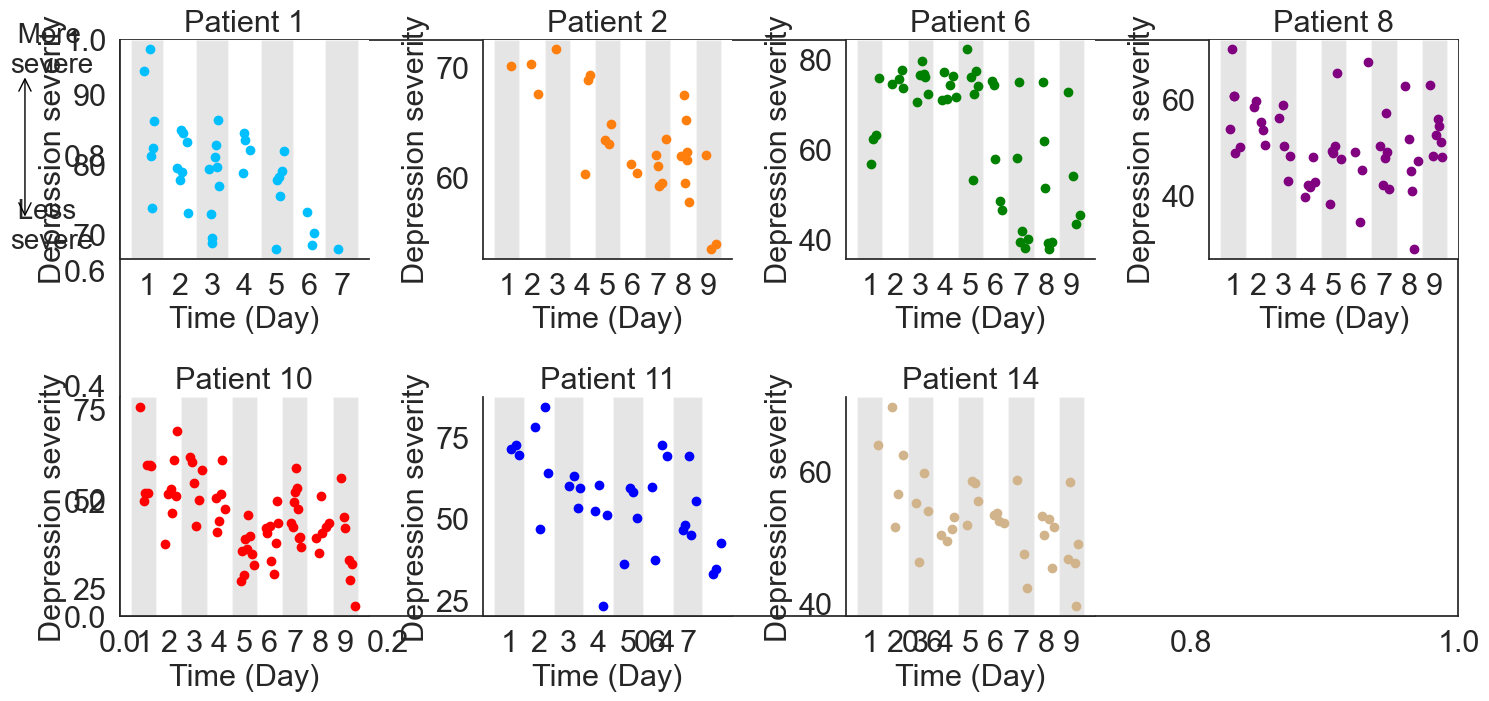

In [4]:
# # Fig2(1): Fluctuation of depression severity throughout inpatient monitoring period 

fig, ax = plt.subplots(figsize=(16,8))
ax = plt.subplot(2, 4, 1)
temp_sbj_name='DBSTRD001'
plot_CATDI(temp_sbj_name,ax)
#ax.annotate(text='a',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
ax = plt.subplot(2, 4, 2)
temp_sbj_name='DBSTRD002'
plot_CATDI(temp_sbj_name,ax)
#ax.annotate(text='b',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
ax = plt.subplot(2, 4, 3)
temp_sbj_name='DBSTRD006'
plot_CATDI(temp_sbj_name,ax)

ax = plt.subplot(2, 4, 4)
temp_sbj_name='DBSTRD008'
plot_CATDI(temp_sbj_name,ax)
#ax.annotate(text='c',xy=(-0.2,1),xycoords='axes fraction',weight="bold")

ax = plt.subplot(2, 4, 5)
temp_sbj_name='DBSTRD010'
plot_CATDI(temp_sbj_name,ax)

ax = plt.subplot(2, 4, 6)
temp_sbj_name='DBSTRD011'
plot_CATDI(temp_sbj_name,ax)

ax = plt.subplot(2, 4, 7)
temp_sbj_name='DBSTRD014'
plot_CATDI(temp_sbj_name,ax)

fig.tight_layout()


--- DEBUG: plot_r_allregion ---
allblk_task shape (bands, chans, blocks): (6, 142, 36)
y shape: (36,), finite y count: 36
Using 87 channels from regions ['ACC', 'dlPFC', 'OFC', 'vmPFC', 'Amy']
First feature: finite pairs=36, var(x)=0.33126252532664974, var(y)=43.929158950617285
r_all stats: -0.6248689773452746 0.6219544370110289
mean |r|: 0.26805447165536334
Min raw p: 4.6241362273711484e-05
Uncorrected sig count (p<0.05): 195
ScoreList blocks: ['EMU-0240_subj-DBSTRD011_task-CATDI_date-20240717_time-135720', 'EMU-0263_subj-DBSTRD011_task-CATDI_date-20240717_time-172548', 'EMU-0274_subj-DBSTRD011_task-CATDI_date-20240717_time-193928', 'EMU-0281_subj-DBSTRD011_task-CATDI_date-20240718_time-085151', 'EMU-0295_subj-DBSTRD011_task-CATDI_date-20240718_time-131321', 'EMU-0317_subj-DBSTRD011_task-CATDI_date-20240718_time-165330', 'EMU-0335_subj-DBSTRD011_task-CATDI_date-20240718_time-194816', 'EMU-0389_subj-DBSTRD011_task-CATDI_date-20240719_time-121151', 'EMU-0409_subj-DBSTRD011_task-CATDI_d

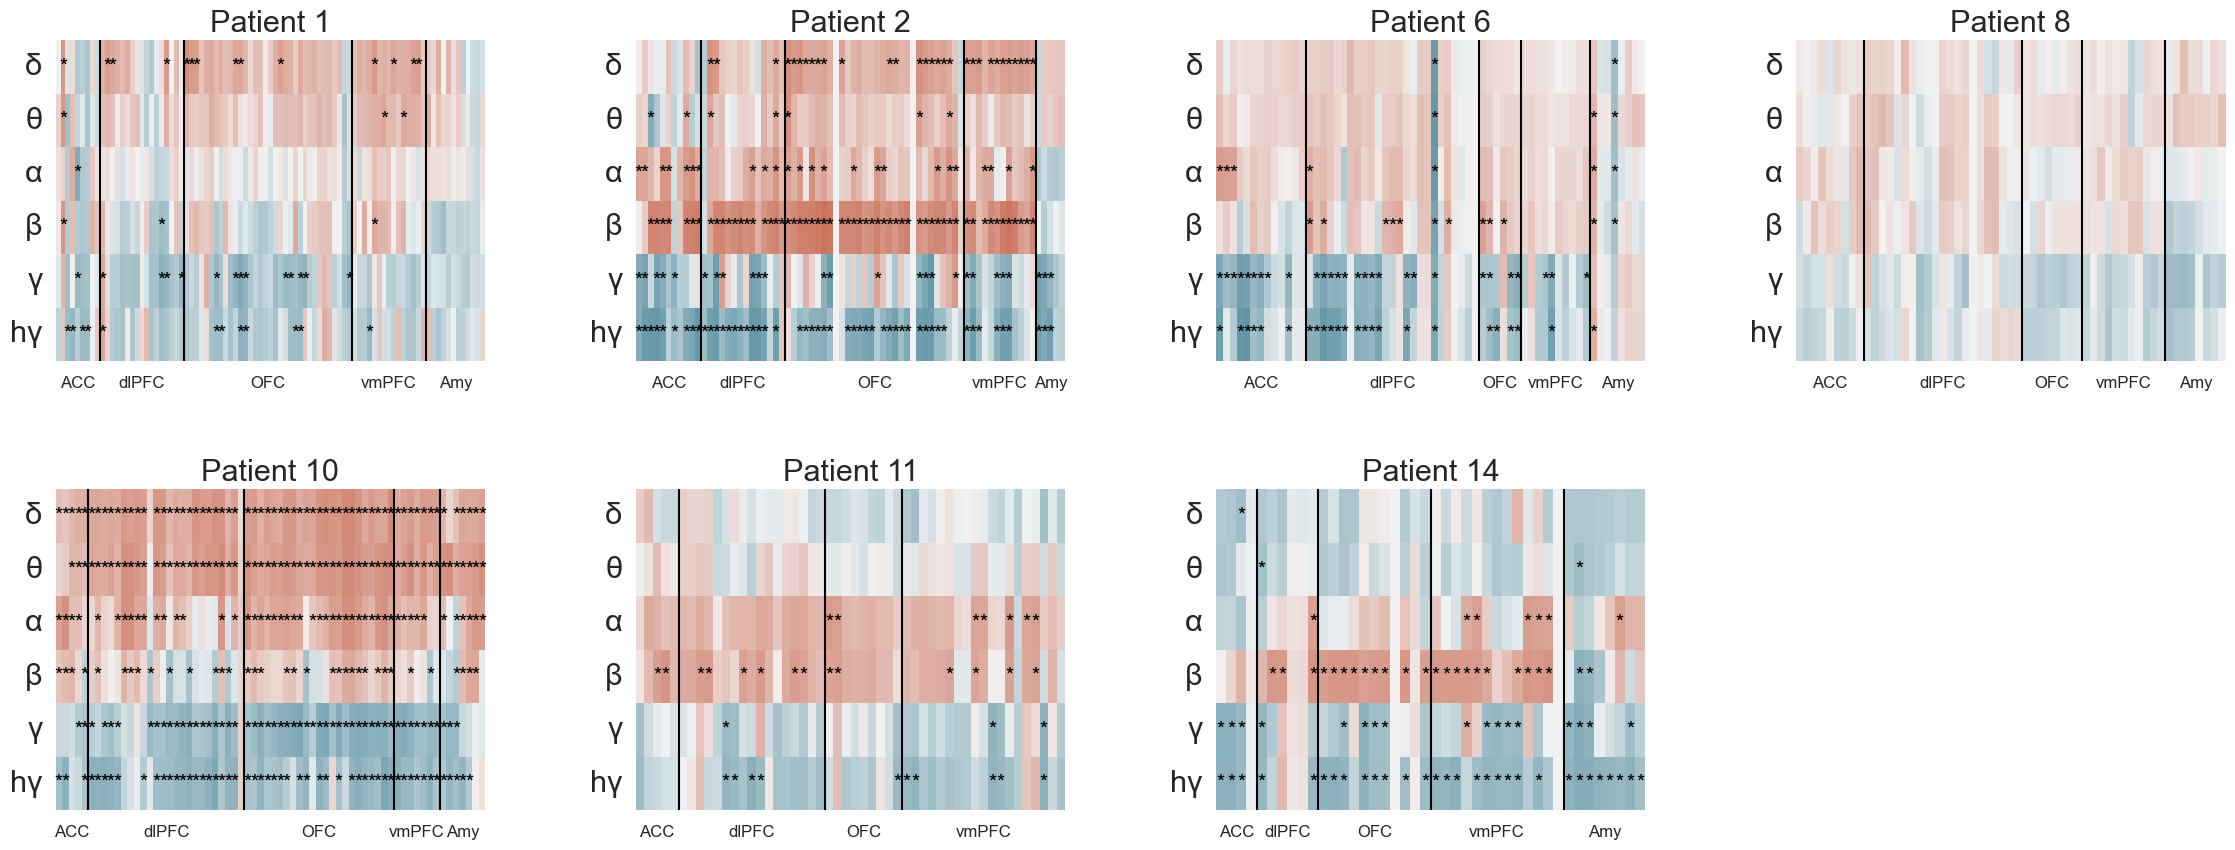

In [5]:
# Fig 2-2
regionname = 'aCC'
bandlist = np.array(['delta','theta','alpha','beta','gamma','highgamma'])
fig = plt.figure(figsize=(28,10))  # a bit wider for 4 panels

# DBSTRD001
temp_sbj_name = 'DBSTRD001'
npzfile = np.load(result_root+'/model/'+temp_sbj_name+'_Raw.npz', allow_pickle=True)
df = pd.read_csv(result_root+'/model/'+temp_sbj_name+'_df.csv')
ax = plt.subplot(2, 4, 1)
plot_r_allregion(npzfile['allblk_task'], npzfile['y'], npzfile['dicts_region2chan'].item(), ax, regionname, df)
#ax.annotate(text='d', xy=(-0.1, 1), xycoords='axes fraction', weight='bold')
plt.yticks(rotation=0)
ax.set_title('Patient 1')

# DBSTRD002
temp_sbj_name = 'DBSTRD002'
npzfile = np.load(result_root+'/model/'+temp_sbj_name+'_Raw.npz', allow_pickle=True)
df = pd.read_csv(result_root+'/model/'+temp_sbj_name+'_df.csv')
ax = plt.subplot(2, 4, 2)
plot_r_allregion(npzfile['allblk_task'], npzfile['y'], npzfile['dicts_region2chan'].item(), ax, regionname, df)
#ax.annotate(text='e', xy=(-0.1, 1), xycoords='axes fraction', weight='bold')
plt.yticks(rotation=0)
ax.set_title('Patient 2')

# DBSTRD006
temp_sbj_name = 'DBSTRD006'
npzfile = np.load(result_root+'/model/'+temp_sbj_name+'_Raw.npz', allow_pickle=True)
df = pd.read_csv(result_root+'/model/'+temp_sbj_name+'_df.csv')
ax = plt.subplot(2, 4, 3)
plot_r_allregion(npzfile['allblk_task'], npzfile['y'], npzfile['dicts_region2chan'].item(), ax, regionname, df)
#ax.annotate(text='f', xy=(-0.1, 1), xycoords='axes fraction', weight='bold')
plt.yticks(rotation=0)
ax.set_title('Patient 6')

# DBSTRD008 (new 4th panel)
temp_sbj_name = 'DBSTRD008'
npzfile = np.load(result_root+'/model/'+temp_sbj_name+'_Raw.npz', allow_pickle=True)
df = pd.read_csv(result_root+'/model/'+temp_sbj_name+'_df.csv')
ax = plt.subplot(2, 4, 4)  # <- give it its own axis
plot_r_allregion(npzfile['allblk_task'], npzfile['y'], npzfile['dicts_region2chan'].item(), ax, regionname, df)
#ax.annotate(text='g', xy=(-0.1, 1), xycoords='axes fraction', weight='bold')
plt.yticks(rotation=0)
ax.set_title('Patient 8')

# DBSTRD010 (new 5th panel)
temp_sbj_name = 'DBSTRD010'
npzfile = np.load(result_root+'/model/'+temp_sbj_name+'_Raw.npz', allow_pickle=True)
df = pd.read_csv(result_root+'/model/'+temp_sbj_name+'_df.csv')
ax = plt.subplot(2, 4, 5)  # <- give it its own axis
plot_r_allregion(npzfile['allblk_task'], npzfile['y'], npzfile['dicts_region2chan'].item(), ax, regionname, df)
#ax.annotate(text='g', xy=(-0.1, 1), xycoords='axes fraction', weight='bold')
plt.yticks(rotation=0)
ax.set_title('Patient 10')

# DBSTRD011 (new 6th panel)
temp_sbj_name = 'DBSTRD011'
npzfile = np.load(result_root+'/model/'+temp_sbj_name+'_Raw.npz', allow_pickle=True)
df = pd.read_csv(result_root+'/model/'+temp_sbj_name+'_df.csv')
ax = plt.subplot(2, 4, 6)  # <- give it its own axis
plot_r_allregion(npzfile['allblk_task'], npzfile['y'], npzfile['dicts_region2chan'].item(), ax, regionname, df)
#ax.annotate(text='g', xy=(-0.1, 1), xycoords='axes fraction', weight='bold')
plt.yticks(rotation=0)
ax.set_title('Patient 11')

# DBSTRD014 (new 6th panel)
temp_sbj_name = 'DBSTRD014'
npzfile = np.load(result_root+'/model/'+temp_sbj_name+'_Raw.npz', allow_pickle=True)
df = pd.read_csv(result_root+'/model/'+temp_sbj_name+'_df.csv')
ax = plt.subplot(2, 4, 7)  # <- give it its own axis
plot_r_allregion(npzfile['allblk_task'], npzfile['y'], npzfile['dicts_region2chan'].item(), ax, regionname, df)
#ax.annotate(text='g', xy=(-0.1, 1), xycoords='axes fraction', weight='bold')
plt.yticks(rotation=0)
ax.set_title('Patient 14')

plt.subplots_adjust(wspace=0.35, hspace=0.4)

In [29]:
# save dicts for Fig3
sbj_name = "DBSTRD008"
cv_outer = LeaveOneOut()
cv_inner = LeaveOneOut()
l1_reg_list=np.around(np.arange(0.1,1.1,0.1),1)
num_selectedregion=1
regionlist=['ACC','dlPFC','OFC', 'vmPFC','AMY']

def region_selection_return_dicts(x,y,l1_reg_list,cv,regionlist,num_selectedregion,dicts_region2chan):
    outlier_thre=4
    removeoutlier=True
    dicts = {}
    dicts_l1_reg={}
    for regionname in itertools.combinations(regionlist, num_selectedregion):
        if num_selectedregion==1:
            x_subset=x[:,dicts_region2chan[regionname[0]],:]
        elif num_selectedregion==2:
            x_subset=x[:,np.concatenate((dicts_region2chan[regionname[0]],dicts_region2chan[regionname[1]])),:]
        x_subset=np.transpose(x_subset.reshape(-1,x_subset.shape[2])) #(trial,feature)
        select_l1_reg=[]
        for l1_reg_index in range(0,len(l1_reg_list)):
            l1_reg=l1_reg_list[l1_reg_index]
            model = make_pipeline(StandardScaler(),Lasso(alpha=l1_reg,max_iter=1000,random_state=0)) 
            list_y_pred=[]
            list_y_test=[]
            for trainval_index, test_index in cv.split(y):
                x_trainval, x_test = x_subset[trainval_index], x_subset[test_index]
                y_trainval, y_test = y[trainval_index], y[test_index] 
                if removeoutlier==True:
                    ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_trainval)>outlier_thre*np.std(x_trainval,axis=0)
                    x_trainval=np.where(ourliermask,np.mean(x_trainval,axis=0),x_trainval)
                    ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_test)>outlier_thre*np.std(x_trainval,axis=0)
                    x_test=np.where(ourliermask,np.mean(x_trainval,axis=0),x_test)
                model.fit(x_trainval, y_trainval)
                y_pred=model.predict(x_test)
                list_y_pred.append(y_pred)
                list_y_test.append(y_test)
            all_y_pred=np.concatenate(list_y_pred)
            all_y_test=np.concatenate(list_y_test)
            NRMSE_score=twoinputs_cal_NRMSE(all_y_test, all_y_pred)
            select_l1_reg.append(NRMSE_score)

        dicts[regionname] =np.min(select_l1_reg)
        dicts_l1_reg[regionname] =l1_reg_list[np.argmin(select_l1_reg)]
    min_key =min(dicts, key=dicts.get)
    selected_region=min_key
    l1_reg=dicts_l1_reg[selected_region]
    # print(dicts)
    # print(dicts_l1_reg)
    if num_selectedregion==1:
        selected_region=min_key[0]
    elif num_selectedregion==2:
        selected_region=[min_key[0],min_key[1]]
    else:
        raise ValueError('Please select 1 or 2 region')
    return selected_region,l1_reg,dicts

outlier_thre=4
removeoutlier=True
list_error_by_region=[]
list_region_name=[]
for trainval_index, test_index in cv_outer.split(y):
    x_trainval= x[:,:,trainval_index]
    y_trainval= y[trainval_index]
    selected_region,l1_reg,dicts=region_selection_return_dicts(x_trainval,y_trainval,l1_reg_list,cv_inner,regionlist,num_selectedregion,dicts_region2chan)
    list_error_by_region.append(list(dicts.values()))
    list_region_name.append(list(dicts.keys()))

np.savez(result_root+'/model/'+sbj_name+'_dicts',y=y,list_error_by_region=list_error_by_region,list_region_name=list_region_name,allow_pickle=True)

/Users/sophiapouya/miniforge3/envs/dbs/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.647e-01, tolerance: 3.344e-01
  model = cd_fast.enet_coordinate_descent(
/Users/sophiapouya/miniforge3/envs/dbs/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.509e-01, tolerance: 3.347e-01
  model = cd_fast.enet_coordinate_descent(
/Users/sophiapouya/miniforge3/envs/dbs/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the featu

FileNotFoundError: [Errno 2] No such file or directory: '/Users/sophiapouya/workspace/bcm/CATDI/Results/model/DBSTRD002_dicts.npz'

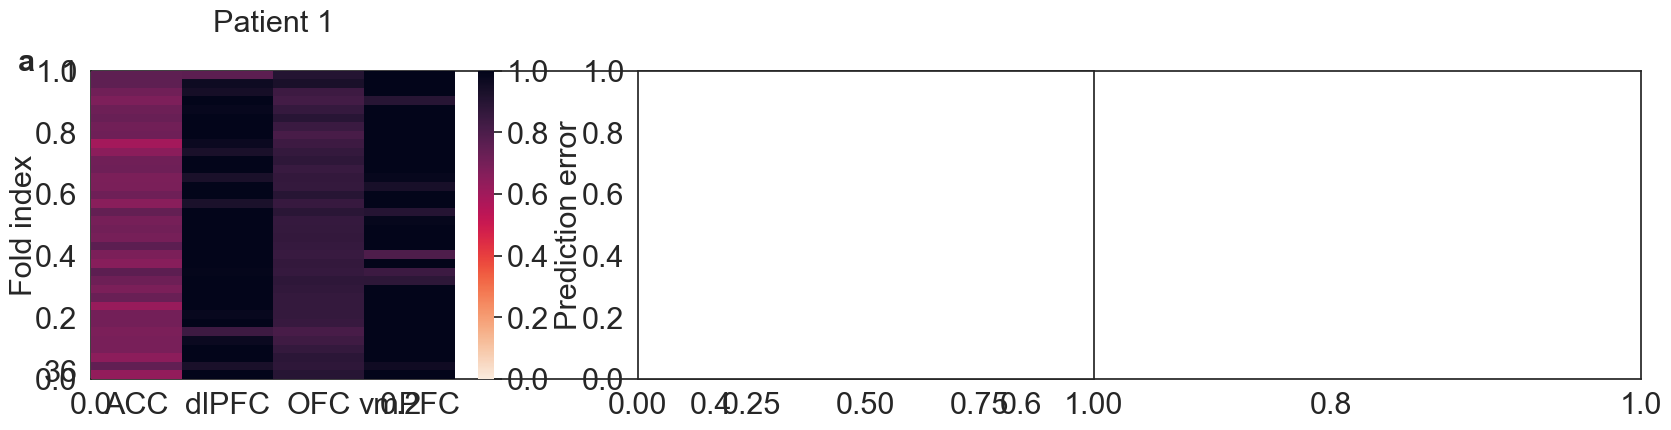

In [7]:
#Fig 3(1) Plot prediction error 
import matplotlib.pyplot as plt
cmap="rocket_r"
fig, ax = plt.subplots(figsize=(20,4))

ax = plt.subplot(1, 3, 1)

temp_sbj_name='DBSTRD001'
dicts_npzfile=np.load(result_root+'/model/'+temp_sbj_name+'_dicts.npz')
list_region_name=dicts_npzfile['list_region_name']
list_error_by_region=dicts_npzfile['list_error_by_region']
y=dicts_npzfile['y']
y_axis_labels=np.arange(1,len(y)+1)
x_axis_labels=[item[0] for item in list_region_name[0]]
colorbarlabel='Prediction error'
ax = sns.heatmap(np.array(list_error_by_region),cmap=cmap,xticklabels=x_axis_labels, yticklabels=False,vmin=0, vmax=1,cbar_kws={'label': colorbarlabel})
yticksposition=np.arange(0,len(y_axis_labels))
ax.set_yticks([yticksposition[0],yticksposition[-1]])
ax.set_yticklabels([y_axis_labels[0],y_axis_labels[-1]])
ax.annotate(text='a',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
ax.set_title('Patient 1',y=1.1)
ax.set_ylabel('Fold index')

ax = plt.subplot(1, 3, 2)
temp_sbj_name='DBSTRD002'
dicts_npzfile=np.load(result_root+'/model/'+temp_sbj_name+'_dicts.npz')
list_region_name=dicts_npzfile['list_region_name']
list_error_by_region=dicts_npzfile['list_error_by_region']
y=dicts_npzfile['y']
y_axis_labels=np.arange(1,len(y)+1)
x_axis_labels=[item[0] for item in list_region_name[0]]
colorbarlabel='Prediction error'
ax = sns.heatmap(np.array(list_error_by_region),cmap=cmap,xticklabels=x_axis_labels, yticklabels=False,vmin=0, vmax=1,cbar_kws={'label': colorbarlabel})
yticksposition=np.arange(0,len(y_axis_labels))
ax.set_yticks([yticksposition[0],yticksposition[-1]])
ax.set_yticklabels([y_axis_labels[0],y_axis_labels[-1]])
ax.annotate(text='b',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
ax.set_title('Patient 2',y=1.1)
ax.set_ylabel('Fold index')

ax = plt.subplot(1, 3, 3)
temp_sbj_name='DBSTRD006'
dicts_npzfile=np.load(result_root+'/model/'+temp_sbj_name+'_dicts.npz')
list_region_name=dicts_npzfile['list_region_name']
list_error_by_region=dicts_npzfile['list_error_by_region']
y=dicts_npzfile['y']
y_axis_labels=np.arange(1,len(y)+1)
x_axis_labels=[item[0] for item in list_region_name[0]]
colorbarlabel='Prediction error'
ax = sns.heatmap(np.array(list_error_by_region),cmap=cmap,xticklabels=x_axis_labels, yticklabels=False,vmin=0, vmax=1,cbar_kws={'label': colorbarlabel})
yticksposition=np.arange(0,len(y_axis_labels))
ax.set_yticks([yticksposition[0],yticksposition[-1]])
ax.set_yticklabels([y_axis_labels[0],y_axis_labels[-1]])
ax.annotate(text='c',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
ax.set_title('Patient 3',y=1.1)
ax.set_ylabel('Fold index')

fig.tight_layout()

NRMSE: 0.75
r: 0.66
p: 0.000013
NRMSE: 0.75


FileNotFoundError: [Errno 2] No such file or directory: '/Users/sophiapouya/workspace/bcm/CATDI/Results/model/DBSTRD002_perm_LOO_Lasso_score.npz'

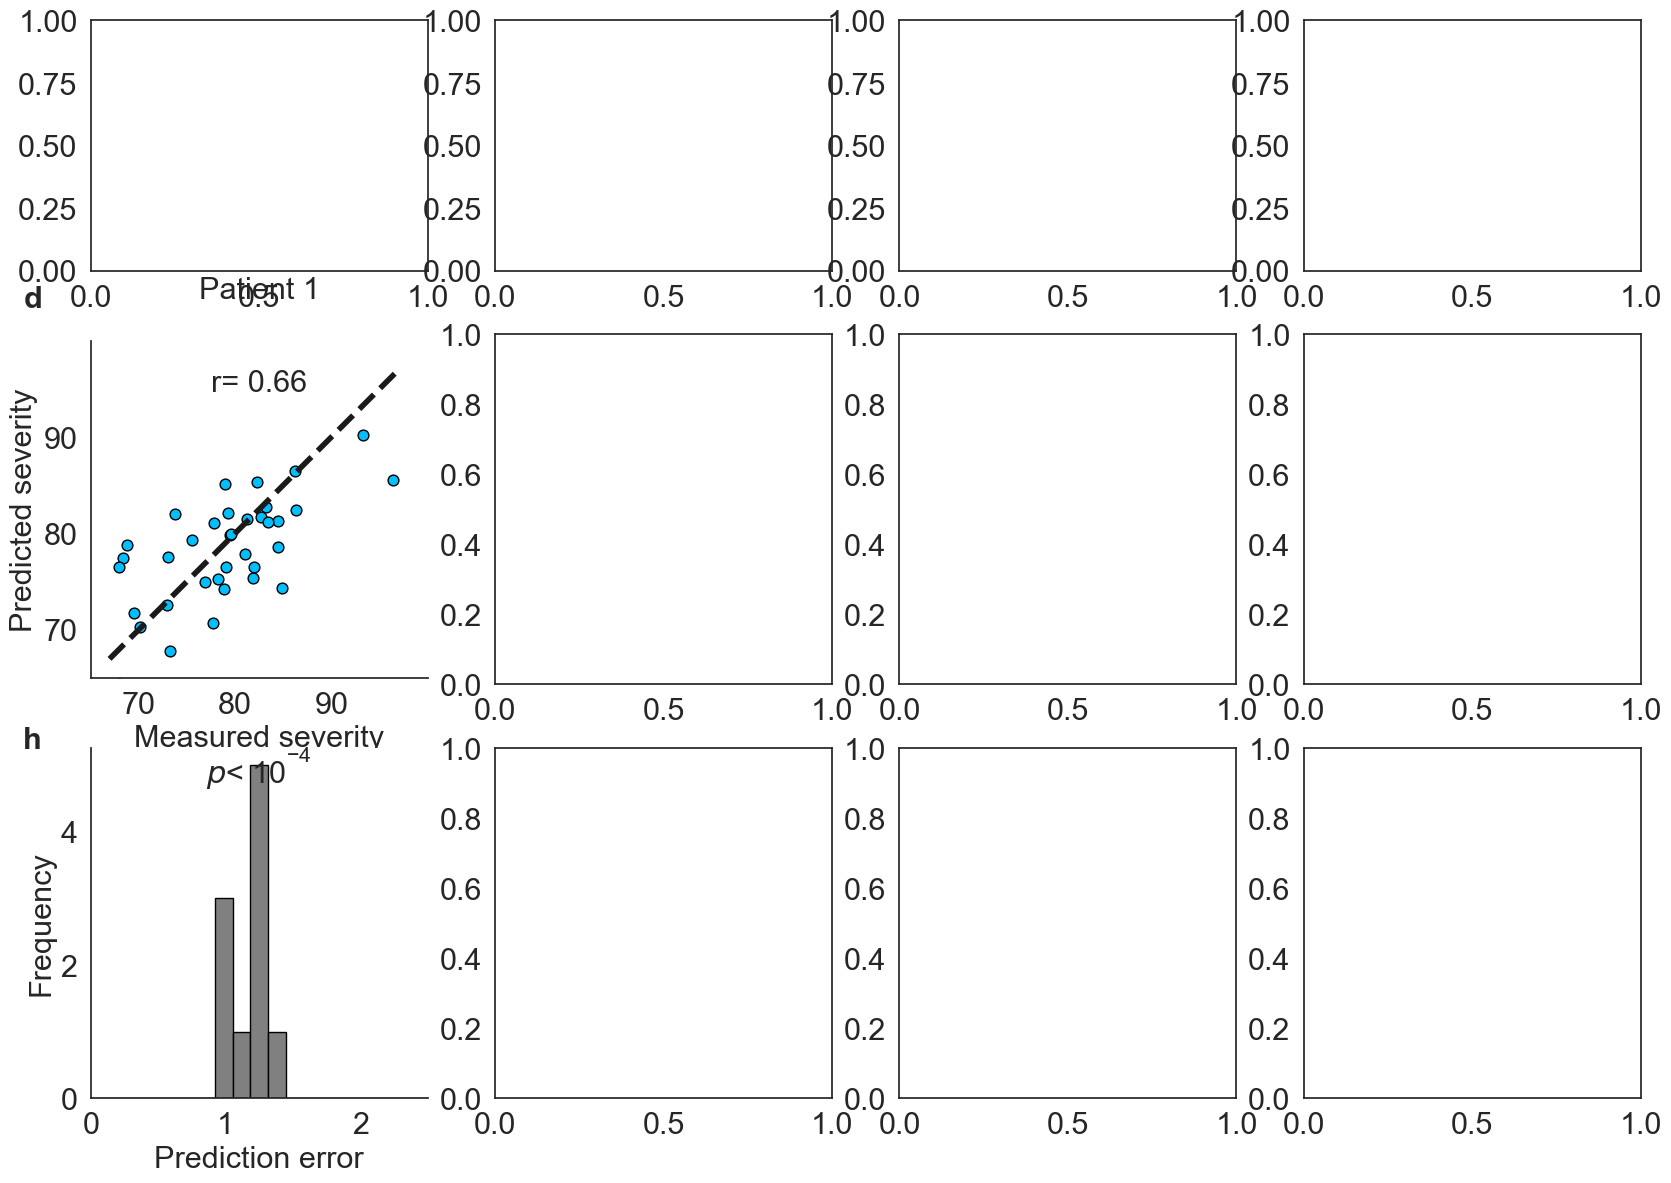

In [26]:
# Fig3 pool(2): 


fig, ax = plt.subplots(3,4,figsize=(20,14),gridspec_kw={'height_ratios': [5,7,7]})

mode='perm'
cv_mode='LOO'
acrossdays=False
use_residual=False
ax = plt.subplot(3, 4, 5)
temp_sbj_name='DBSTRD001'
if acrossdays==True:
    perm_pred,perm_test,perm_NRMSE,true_pred,true_test,true_NRMSE=get_perm_true(result_root,temp_sbj_name,mode,'acrossdays',use_residual)
else:
    perm_pred,perm_test,perm_NRMSE,true_pred,true_test,true_NRMSE=get_perm_true(result_root,temp_sbj_name,mode,cv_mode,use_residual)
if use_residual==True:
    plot_pred_test_residual(cv_mode,true_pred,true_test,ax,1)
else:
    plot_pred_test(cv_mode,true_pred,true_test,ax,1)
ax.annotate(text='d',xy=(-0.2,1.1),xycoords='axes fraction',weight="bold")
ax.set_title('Patient 1',y=1.1)
ax = plt.subplot(3, 4, 9)
plot_permutation(len(perm_NRMSE),perm_NRMSE,true_NRMSE,mode,ax)
ax.annotate(text='h',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
#ax.set_title('Patient 1',y=1.05)

ax = plt.subplot(3, 4, 6)
temp_sbj_name='DBSTRD002'
if acrossdays==True:
    perm_pred,perm_test,perm_NRMSE,true_pred,true_test,true_NRMSE=get_perm_true(result_root,temp_sbj_name,mode,'acrossdays',use_residual)
else:
    perm_pred,perm_test,perm_NRMSE,true_pred,true_test,true_NRMSE=get_perm_true(result_root,temp_sbj_name,mode,cv_mode,use_residual)
if use_residual==True:
    plot_pred_test_residual(cv_mode,true_pred,true_test,ax,2)
else:
    plot_pred_test(cv_mode,true_pred,true_test,ax,2)
ax.annotate(text='e',xy=(-0.2,1.1),xycoords='axes fraction',weight="bold")
ax.set_title('Patient 2',y=1.1)
ax = plt.subplot(3, 4, 10)
plot_permutation(len(perm_NRMSE),perm_NRMSE,true_NRMSE,mode,ax)
ax.annotate(text='i',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
#ax.set_title('Patient 2',y=1.05)

ax = plt.subplot(3, 4, 7)
temp_sbj_name='DBSTRD006'
if acrossdays==True:
    perm_pred,perm_test,perm_NRMSE,true_pred,true_test,true_NRMSE=get_perm_true(result_root,temp_sbj_name,mode,'acrossdays',use_residual)
else:
    perm_pred,perm_test,perm_NRMSE,true_pred,true_test,true_NRMSE=get_perm_true(result_root,temp_sbj_name,mode,cv_mode,use_residual)
if use_residual==True:
    plot_pred_test_residual(cv_mode,true_pred,true_test,ax,3)
else:
    plot_pred_test(cv_mode,true_pred,true_test,ax,3)
ax.annotate(text='f',xy=(-0.2,1.1),xycoords='axes fraction',weight="bold")
ax.set_title('Patient 3',y=1.1)
ax = plt.subplot(3, 4, 11)
plot_permutation(len(perm_NRMSE),perm_NRMSE,true_NRMSE,mode,ax)
ax.annotate(text='j',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
#ax.set_title('Patient 3',y=1.05)

ax = plt.subplot(3, 4, 8)
if use_residual==True:
    npzfile=np.load(result_root+'/model/'+'pool'+'_'+mode+'_'+cv_mode+'_use_residual_Lasso_score.npz',allow_pickle=True)
else:
    npzfile=np.load(result_root+'/model/'+'pool'+'_'+mode+'_'+cv_mode+'_Lasso_score.npz',allow_pickle=True)
x=np.concatenate(npzfile['all_y_test'])
y=np.concatenate(npzfile['all_y_pred'])
if use_residual==True:
    x_label='Measured (z-score)'
    y_label='Predicted (z-score)'
else:
    x_label='Measured severity (z-score)'
    y_label='Predicted severity (z-score)'

colors=['deepskyblue','tab:orange','green']
for fold_index in range(0,len(npzfile['all_y_pred'])):
    ax.scatter(npzfile['all_y_test'][fold_index], npzfile['all_y_pred'][fold_index],s=60,edgecolors=(0, 0, 0),color=colors[fold_index])
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
rvalue,pvalue=stats.pearsonr(x, y)
ax.annotate(text='r= %s'%format(rvalue, '.2f'),xy=(0.5,0.85),xycoords='axes fraction',ha="center")
ax.set_xlim([-2.5,2.5])
ax.set_ylim([-2.5,2.5])
plt.xticks([-2,0,2])
plt.yticks([-2,0,2])
ax.plot([-2.2,2.2], [-2.2,2.2], 'k--', lw=4)
ax.annotate(text='g',xy=(-0.2,1.1),xycoords='axes fraction',weight="bold")
ax.set_title('Pooled across patients',y=1.1)

ax = plt.subplot(3, 4, 12)
plot_permutation_pool(len(npzfile['perm_NRMSE_scores']),npzfile['perm_NRMSE_scores'],npzfile['NRMSE_score'],mode,ax)
ax.annotate(text='k',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
#ax.set_title('Pooled across patients',y=1.05)

fig.tight_layout()

ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
ACC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
dlPFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
OFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1
vmPFC
1


FileNotFoundError: [Errno 2] No such file or directory: '/Users/sophiapouya/workspace/bcm/CATDI/Results/model/DBSTRD002_Raw.npz'

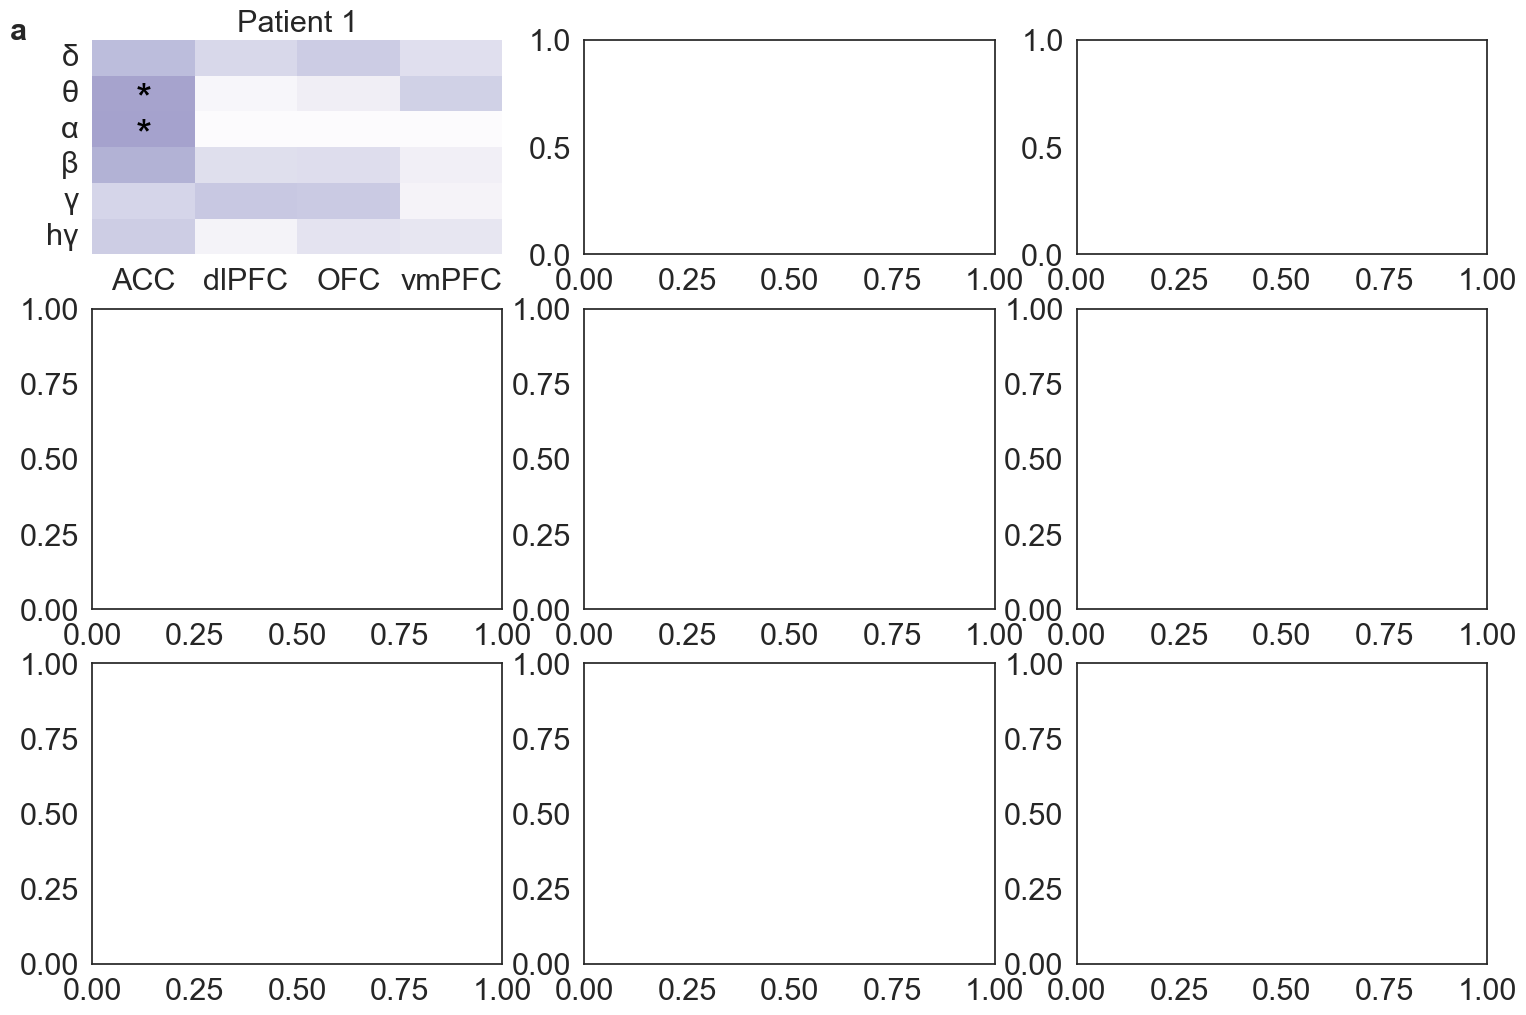

In [29]:
# Fig 4-1 Plot r squared #Neural features in different frequency bands were informative
log_tran=False
fig, ax = plt.subplots(3,3,figsize=(18,12),gridspec_kw={'height_ratios': [5,7,7]})
ax = plt.subplot(3, 3, 1)
temp_sbj_name='DBSTRD001'
npzfile=np.load(result_root+'/model/'+temp_sbj_name+'_Raw.npz',allow_pickle=True)
plot_rsquared(npzfile['allblk_task'],npzfile['y'],npzfile['dicts_region2chan'].item(),ax)
ax.annotate(text='a',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
plt.yticks(rotation=0) 
ax.set_title('Patient 1')

ax = plt.subplot(3, 3, 2)
temp_sbj_name='DBSTRD002'
npzfile=np.load(result_root+'/model/'+temp_sbj_name+'_Raw.npz',allow_pickle=True)
plot_rsquared(npzfile['allblk_task'],npzfile['y'],npzfile['dicts_region2chan'].item(),ax)
ax.annotate(text='b',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
plt.yticks(rotation=0) 
ax.set_title('Patient 2')

ax = plt.subplot(3, 3, 3)
temp_sbj_name='DBSTRD006'
npzfile=np.load(result_root+'/model/'+temp_sbj_name+'_Raw.npz',allow_pickle=True)
plot_rsquared(npzfile['allblk_task'],npzfile['y'],npzfile['dicts_region2chan'].item(),ax)
ax.annotate(text='c',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
plt.yticks(rotation=0) 
ax.set_title('Patient 3')
# plt.savefig(result_root+'/All_sbj/Fig4_1.svg',dpi=300)

ax = plt.subplot(3, 3, 4)
ax.annotate(text='d',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
ax.axis('off')
ax = plt.subplot(3, 3, 5)
ax.annotate(text='e',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
ax.axis('off')
ax = plt.subplot(3, 3, 6)
ax.annotate(text='f',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
ax.axis('off')
ax = plt.subplot(3, 3, 7)
ax.annotate(text='g',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
ax.axis('off')
ax = plt.subplot(3, 3, 8)
ax.annotate(text='h',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
ax.axis('off')
ax = plt.subplot(3, 3, 9)
ax.annotate(text='i',xy=(-0.2,1),xycoords='axes fraction',weight="bold")
ax.axis('off')
fig.tight_layout()

In [30]:
#Fig 4-2/3 calculation Plot selected features when using different alpha values
warnings.filterwarnings('ignore')
outlier_thre=4
chanlist=[int(s)-1 for s in df.Electrode.values]

region_groups=df.region.values
regionband_groups_name=[]
for bandname in bandlist:
    regionband_groups_name.append(region_groups)
regionband_groups_name=np.concatenate(regionband_groups_name)
LE = LabelEncoder()
regionband_groups = LE.fit_transform(regionband_groups_name)
print(LE.classes_)

df['Label2']=df.region.values+'_'+[x[0] for x in df.hemi.values]+'_'+[item.split('-')[1] for item in df.Label.values]
bandlist=['δ','θ','α','β','γ','hγ']
region_groups=df.Label2.values
features_name=[]
for bandname in bandlist:
    features_name.append(df.region.values+' '+bandname+'_'+df.hemi.values+'_'+[item.split('-')[1] for item in df.Label.values])
features_name=np.concatenate(features_name)

mapping = [ ('δ','band1'), ('θ','band2'), ('α','band3'), ('β','band4'), ('γ','band5') , ('hγ','band6'),
          ('ACC','region1'), ('dlPFC','region2'), ('OFC','region3'), ('vmPFC','region4')]
new_features_name=[]
for string_index in range(0,len(features_name)):
    my_string=features_name[string_index]
    for k, v in mapping:
        my_string = my_string.replace(k, v)        
    new_features_name.append(my_string)
new_features_name=np.array(new_features_name)    

cv_outer = LeaveOneOut()
alpha_list=np.around(np.arange(0.1,5.1,0.1),1)
error_list=[]
record_features_name=[]
record_features_coef=[]
for alpha in alpha_list:
    #print(alpha)
    
    list_y_pred=[]
    list_y_test=[]
    for trainval_index, test_index in cv_outer.split(y):
        x_selected=x[:,chanlist,:]
        x_selected=np.transpose(x_selected.reshape(-1,x_selected.shape[2])) #(trial,feature)
        x_trainval, x_test = x_selected[trainval_index], x_selected[test_index]
        y_trainval, y_test = y[trainval_index], y[test_index]   
        
        ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_trainval)>outlier_thre*np.std(x_trainval,axis=0)
        x_trainval=np.where(ourliermask,np.mean(x_trainval,axis=0),x_trainval)
        ourliermask=np.abs(np.mean(x_trainval,axis=0)-x_test)>outlier_thre*np.std(x_trainval,axis=0)
        x_test=np.where(ourliermask,np.mean(x_trainval,axis=0),x_test)
       
        model = make_pipeline(StandardScaler(),Lasso(alpha=alpha))
        model.fit(x_trainval, y_trainval)
        y_pred=model.predict(x_test)
        list_y_pred.append(y_pred)
        list_y_test.append(y_test)
        #print(new_features_name[model['lasso'].coef_!=0])

    all_y_pred=np.concatenate(list_y_pred)
    all_y_test=np.concatenate(list_y_test)
    error=twoinputs_cal_NRMSE(all_y_test, all_y_pred)
    error_list.append(error)

    model = make_pipeline(StandardScaler(),Lasso(alpha=alpha))
    model.fit(x_selected, y)
    #print(alpha)
    record_features_name.append(new_features_name[model['lasso'].coef_!=0])
    record_features_coef.append(model['lasso'].coef_)
    
sorted_features_name=sorted(new_features_name)

barcode=[]
for alpha_index in range(0,len(alpha_list)):
    barcode.append(np.in1d(sorted_features_name, record_features_name[alpha_index]))

new_sorted_features_name=[]
mapping = [ ('band1','δ'), ('band2','θ'), ('band3','α'), ('band4','β'), ('band5','γ') , ('band6','hγ'),
          ('region1', 'ACC'), ('region2', 'dlPFC'), ('region3', 'OFC'), ('region4', 'vmPFC')]
for string_index in range(0,len(sorted_features_name)):
    my_string=sorted_features_name[string_index]
    for k, v in mapping:
        my_string = my_string.replace(k, v)        
    new_sorted_features_name.append(my_string)

['ACC' 'OFC' 'dlPFC' 'vmPFC']


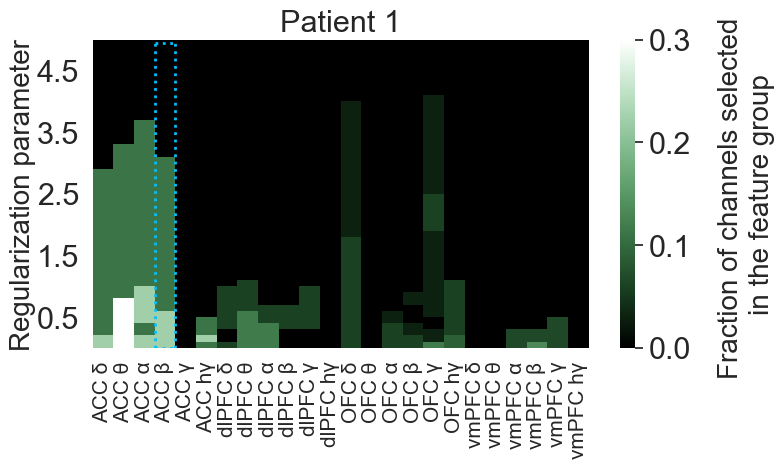

In [31]:
#Fig 4-3 
if sbj_name=='DBSTRD001':
    group_index=3
elif sbj_name=='DBSTRD002':
    group_index=17
elif sbj_name=='DBSTRD006':
    group_index=5
if sbj_name=='DBSTRD006':
    sbj_name='DBSTRD003'
colors=['deepskyblue','tab:orange','green']
groupnames=np.array([x.split('_')[0] for x in  new_sorted_features_name])
store_group=[]
for groupindex in np.arange(0,len(pd.unique(groupnames))):
    groupname=pd.unique(groupnames)[groupindex]
    store_group.append(np.mean(np.array(barcode).astype(int)[:,np.where(groupnames==groupname)[0]],axis=-1))
store_group=np.flip(np.transpose(store_group),axis=0)
fig, ax = plt.subplots(figsize=(8,4))
ax = plt.subplot(111)
ax = sns.heatmap(store_group,xticklabels=pd.unique(groupnames),yticklabels=False, vmin=0, vmax=0.3,cmap=sns.cubehelix_palette(start=2, rot=0, dark=0, light=1, reverse=True, as_cmap=True),
                 cbar_kws={'label': 'Fraction of channels selected'})#, cbar=False)

cbar = ax.collections[0].colorbar
cbar.set_label('Fraction of channels selected \nin the feature group', labelpad=20, fontsize = 20)
yticksposition=np.arange(0,len(alpha_list))
ax.set_yticks(yticksposition[5::10])
ax.set_yticklabels(np.around(np.flip(alpha_list),2)[5::10].astype('U'))#,fontsize = 15)
ax.set_xticklabels(labels=pd.unique(groupnames),fontsize = 15)
ax.text(x=-4,y=(yticksposition[0]+yticksposition[-1])/2+25,s='Regularization parameter',rotation=90, fontsize = 20)#,fontsize = 15)
ax.set_title('Patient '+sbj_name[-1])
plt.axvline(x=ax.get_xticks()[group_index]-0.5,ymin=yticksposition[0],ymax=yticksposition[-1],linewidth=2,color=colors[int(sbj_name[-1])-1],linestyle='dotted')
plt.axvline(x=ax.get_xticks()[group_index]+0.5,ymin=yticksposition[0],ymax=yticksposition[-1],linewidth=2,color=colors[int(sbj_name[-1])-1],linestyle='dotted')
ax.plot((ax.get_xticks()[group_index]-0.5, ax.get_xticks()[group_index]+0.5), (yticksposition[0]+0.5, yticksposition[0]+0.5),linewidth=2,color=colors[int(sbj_name[-1])-1],linestyle='dotted')
ax.plot((ax.get_xticks()[group_index]-0.5, ax.get_xticks()[group_index]+0.5), (yticksposition[-1]+1, yticksposition[-1]+1),linewidth=2,color=colors[int(sbj_name[-1])-1],linestyle='dotted')

Text(0.5, 0.9, 'Patient 1\nACC β')

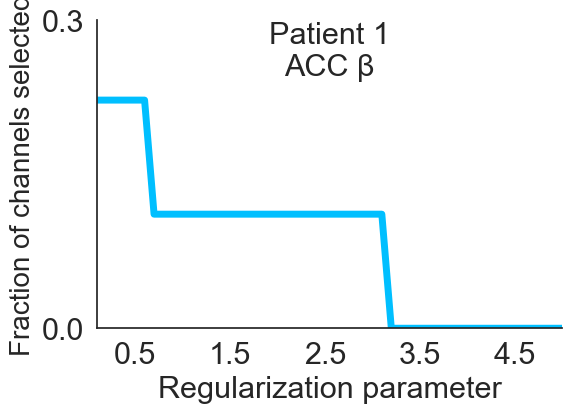

In [32]:
#Fig 4-2 
fig, ax = plt.subplots(figsize=(6,4))
ax = plt.subplot(111)
plt.plot(alpha_list,np.flip(np.array(store_group)[:,group_index]),linewidth=5,color=colors[int(sbj_name[-1])-1])
xticksposition=alpha_list
ax.set_xticks(xticksposition[4::10])
ax.set_xticklabels(np.around(alpha_list,2)[4::10].astype('U'))#,fontsize = 15))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel('Regularization parameter')
ax.set_ylabel('Fraction of channels selected',fontsize = 20)
ax.set_ylim([0,0.3])
ax.set_yticks([0,0.3])
ax.set_xlim([0.1,5])
ax.text(s='Patient '+sbj_name[-1]+'\n'+pd.unique(groupnames)[group_index],x=0.5,y=0.9, horizontalalignment='center',
     verticalalignment='center', transform=ax.transAxes)

# Permutation Calculation

In [19]:
%%time
print(mp.cpu_count()) 
warnings.filterwarnings('ignore')

regionselection=True
use_residual=False
mode='perm'
cv_mode='LOO'
#cv_mode='Kfold'
#cv_mode='acrossdays'
sbj_name='DBSTRD001'

if cv_mode=='LOO' :
    npzfile=np.load(result_root+'/model/'+sbj_name+'_Raw.npz',allow_pickle=True)
    cv_outer = LeaveOneOut()
if cv_mode=='Kfold':
    npzfile=np.load(result_root+'/model/'+sbj_name+'_Raw.npz',allow_pickle=True)
    cv_outer = KFold(n_splits=5,shuffle=True,random_state=int(sbj_name[-1]))
    if sbj_name=='DBSTRD006':
        cv_outer = KFold(n_splits=5,shuffle=True,random_state=3)
if cv_mode=='acrossdays':
    npzfile=np.load(result_root+'/model/'+sbj_name+'_Raw_acrossday.npz',allow_pickle=True)
    cv_outer = LeaveOneOut()

if use_residual==True:
    y=npzfile['y_residual']
else:
    y=npzfile['y']
    
allblk_task=npzfile['allblk_task']
dicts_region2chan=npzfile['dicts_region2chan'].item()
used_contacts=np.concatenate(list(dicts_region2chan.values())) #For no selection
x=allblk_task
if log_tran==True:
    x=10*np.log10(x)

cv_inner = LeaveOneOut()
l1_reg_list=np.around(np.arange(0.1,1.1,0.1),1)
num_selectedregion=1
# Permutation calculation
n_permutations=10
np.random.seed(0)

if regionselection==True:
    NRMSE_score=region_model_Multprocess(y)
else:
    NRMSE_score=noselection_model_Multprocess(y)
    
copy_of_y = y.copy() 

y_shuffle_list=[]
for i in range(0,n_permutations):
    if mode=='perm':
        y_shuffle=shuffle(copy_of_y,random_state=i)
    if mode=='random':
        y_shuffle=np.array(random.Random(i).choices(np.arange(np.min(copy_of_y),np.max(copy_of_y)+0.1,0.1).tolist(),k=len(copy_of_y)))
    if mode=='halfperm':
        y_shuffle=np.concatenate([shuffle(copy_of_y[0:int(copy_of_y.shape[0]/2)],random_state=i),shuffle(copy_of_y[int(copy_of_y.shape[0]/2):int(copy_of_y.shape[0])+1],random_state=i)])
    y_shuffle_list.append(y_shuffle)

if regionselection:
    with mp.Pool(processes=15) as pool:
        perm_NRMSE_scores = list(tqdm(pool.imap(region_model_Multprocess, y_shuffle_list), total=n_permutations))
else:
    with mp.Pool(processes=15) as pool:
        perm_NRMSE_scores = list(tqdm(pool.imap(noselection_model_Multprocess, y_shuffle_list), total=n_permutations))

# Save with correct array structure
filename = f"{result_root}/model/{sbj_name}_{mode}_{cv_mode}"
if regionselection:
    if use_residual:
        filename += "_use_residual_Lasso_score"
    else:
        filename += "_Lasso_score"
else:
    filename += "_noselection_Lasso_score"

np.savez(
    filename,
    NRMSE_score=np.array(NRMSE_score, dtype=object),
    perm_NRMSE_scores=np.array(perm_NRMSE_scores, dtype=object),
    perm_pred=np.array(perm_pred, dtype=object),
    perm_test=np.array(perm_test, dtype=object),
    allow_pickle=True
)

14


  0%|          | 0/10 [00:00<?, ?it/s]

CPU times: user 52.5 s, sys: 457 ms, total: 52.9 s
Wall time: 2min 1s


In [20]:
npz = np.load(result_root+'/model/DBSTRD001_perm_LOO_Lasso_score.npz', allow_pickle=True)
print("Available keys:", npz.files)
perm_NRMSE_scores = npz["perm_NRMSE_scores"]
print(type(perm_NRMSE_scores[0]))  # should be <class 'tuple'>
print(len(perm_NRMSE_scores))      # should be 1000 (or however many permutations you ran)
print(len(perm_NRMSE_scores[0]))   # should be 3 → (pred, test, NRMSE)

Available keys: ['NRMSE_score', 'perm_NRMSE_scores', 'perm_pred', 'perm_test']
<class 'numpy.ndarray'>
10
3
